In [1]:
%%capture --no-stderr
%pip install -U langchain_openai langgraph trustcall langchain_core

%pip install langchain_community

%pip install faiss-cpu

In [2]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import sys
sys.path.append('/content/drive/MyDrive/Baot/30_NLP_2025/Tair')

In [5]:
from graph_nodes_V6 import State, assistant, upload_image, display_image, identify_food, get_calories, get_image_path_node
# from graph_nodes_V6 import tools , tools_condition

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import importlib
import graph_nodes_V6
importlib.reload(graph_nodes_V6)
from graph_nodes_V6 import State, assistant, get_image_path, upload_image, display_image, identify_food, get_calories # get_image_path_node
# from graph_nodes_V6 import tools , tools_condition


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
from langgraph.graph import StateGraph, START, END, MessagesState

from langgraph.prebuilt import ToolNode

from langchain_core.runnables import RunnableConfig, Runnable
from langchain_core.messages import merge_message_runs, HumanMessage, SystemMessage, AIMessage, ToolMessage, ToolCall

from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore

from langgraph.checkpoint.memory import MemorySaver

from langchain_openai import ChatOpenAI

from trustcall import create_extractor
from typing import TypedDict, Literal, Union, Optional, List, Dict, Any

from pydantic import BaseModel, Field

from datetime import datetime

import uuid

from graph_nodes_V6 import State, assistant, upload_image, display_image, identify_food, get_calories, get_image_path
# from graph_nodes_V6 import State, assistant, upload_image, display_image_modified, identify_food_modified, get_calories_modified, get_image_path_node

# from graph_nodes_V6 import tools , tools_condition
from rag import get_rag

from IPython.display import Image, display


In [8]:
from langchain_core.runnables import RunnableConfig, Runnable, RunnableLambda
from langchain_core.messages import merge_message_runs, HumanMessage, SystemMessage, AIMessage, ToolMessage, ToolCall


In [9]:
# Initialize the model
llm = ChatOpenAI(model="gpt-4o")

rag_chain = get_rag(llm)

'''
Trustcall creates and updates JSON schemas:

# Add a listener to the Trustcall extractor. This will pass runs from the extractor's execution to a class, `Spy`.
`Spy` class will extract information about what tool calls were made by Trustcall.
'''
# Inspect the tool calls made by Trustcall
class Spy:
    def __init__(self):
        self.called_tools = []

    def __call__(self, run):
        # Collect information about the tool calls made by the extractor.
        q = [run]
        while q:
            r = q.pop()
            if r.child_runs:
                q.extend(r.child_runs)
            if r.run_type == "chat_model":
                self.called_tools.append(
                    r.outputs["generations"][0][0]["message"]["kwargs"]["tool_calls"]
                )

# Initialize the spy
spy = Spy()

def extract_tool_info(tool_calls, schema_name="Memory"):
    """Extract information from tool calls for both patches and new memories.

    Args:
        tool_calls: List of tool calls from the model
        schema_name: Name of the schema tool (e.g., "Memory", "ToDo", "Profile")
    """

    # Initialize list of changes
    changes = []

    for call_group in tool_calls:
        for call in call_group:
            if call['name'] == 'PatchDoc':
                changes.append({
                    'type': 'update',
                    'doc_id': call['args']['json_doc_id'],
                    'planned_edits': call['args']['planned_edits'],
                    'value': call['args']['patches'][0]['value']
                })
            elif call['name'] == schema_name:
                changes.append({
                    'type': 'new',
                    'value': call['args']
                })

    # Format results as a single string
    result_parts = []
    for change in changes:
        if change['type'] == 'update':
            result_parts.append(
                f"Document {change['doc_id']} updated:\n"
                f"Plan: {change['planned_edits']}\n"
                f"Added content: {change['value']}"
            )
        else:
            result_parts.append(
                f"New {schema_name} created:\n"
                f"Content: {change['value']}"
            )

    return "\n\n".join(result_parts)

# Creating an agent

# Update memory tool
class UpdateMemory(TypedDict):
    """ Decision on what memory type to update """
    update_type: Literal['user', 'eating_plan', 'instructions']

################################################################################
# Graph definition

# User profile schema
class Profile(BaseModel):
    """This is the profile of the user you are chatting with"""
    name: Optional[str] = Field(description="The user's name", default=None)
    age: Optional[int] = Field(description="The user's age", default=None)
    weight: Optional[float] = Field(description="The user's weight", default=None)
    height: Optional[float] = Field(description="The user's height", default=None)
    gender: Optional[str] = Field(description="The user's gender", default=None)
    exercise_level: Optional[str] = Field(description="The user's  (amount of time spends on sport weekly)", default=None)
    diet_type: Optional[str] = Field(description="The user's diexercise level type", default=None)
    allergies: Optional[List[str]] = Field(description="The user's allergies",default_factory=list)
    medications: Optional[List[str]] = Field(description="The user's medications", default_factory=list)
    habits: Optional[List[str]] = Field(description="The user's habits", default_factory=list)
    preferences: Optional[List[str]] = Field(description="The user's preferences", default_factory=list)
    location: Optional[str] = Field(description="The user's location", default=None)
    job: Optional[str] = Field(description="The user's job", default=None)
    diet_goals: list[str] = Field(
        description="The user's dietary goals for which they are seeking advice, such as losing or gaining weight, improving fitness, addressing dietary restrictions like gluten intolerance.",
        default_factory=list
    )
    interests: list[str] = Field(
        description="Interests that the user has",
        default_factory=list
    )

    def estimated_tdee(self) -> Optional[float]:
        if self.weight and self.height and self.age and self.gender:
            if self.gender.lower() == "male":
                bmr = 10 * self.weight + 6.25 * self.height - 5 * self.age + 5
            else:
                bmr = 10 * self.weight + 6.25 * self.height - 5 * self.age - 161

            activity_multiplier = {
                "low": 1.2,
                "medium": 1.55,
                "high": 1.9
            }.get((self.exercise_level or "medium").lower(), 1.55)

            return round(bmr * activity_multiplier, 2)
        return None

###############################################################################
'''
***RECOMMODATION TOOL*** - called after calories estimations and user prompt.
This function does not align with the course notebook!! make sure it is truly needed.
Justification - The recommodation part is been doing in after the estimate calories is done.
It is a tool that takes the calories estimations and based on the user profile and eating history
gives specific recommendations to the user.
Make sure the implementation is the best practice.
'''
# # Define the input schema for the tool
# class FoodAdviserInputSchema(BaseModel):
#     input_data: str  # The dish description or ingredients
#     user_profile: Optional[Dict[str, Any]] = None  # Optional user profile to override what’s in memory

# # Define the tool wrapper
# class ToolWrapper:
#     def __init__(self, func, name: str, description: str, input_schema: BaseModel):
#         self.func = func
#         self.name = name
#         self.description = description
#         self.input_schema = input_schema

#     def invoke(self, input: Union[BaseModel, Dict[str, Any]], config: Optional[RunnableConfig] = None):
#         if isinstance(input, dict):
#             validated_input = self.input_schema(**input)
#         else:
#             validated_input = input
#         return self.func(**validated_input.model_dump(), config=config)

#     def __call__(self, input, config: Optional[RunnableConfig] = None):
#         return self.invoke(input, config)

#     def to_openai_function(self) -> Dict:
#         return {
#             "type": "function",
#             "function": {
#                 "name": self.name,
#                 "description": self.description,
#                 "parameters": self.input_schema.model_json_schema()
#             }
#         }

# # Bind the function to the tool (you already have the logic in `process_food_adviser`)
# def food_adviser_function(input_data: str, user_profile: Optional[Dict[str, Any]] = None, config: Optional[RunnableConfig] = None):
#     # You can leave this empty because `process_food_adviser` does the work,
#     # or just use this as a dummy to meet the interface.
#     return f"Processed input: {input_data} with profile: {user_profile}"

# # Instantiate the tool for registration
# food_adviser_tool = ToolWrapper(
#     func=food_adviser_function,
#     name="FoodAdviser",
#     description="Provides food recommendations and calorie estimates based on profile and dish input.",
#     input_schema=FoodAdviserInputSchema
# )

################################################################################

# EatingPlan schema
'''
TO BE CHANGE!!!!!!
Think carefully about this schema. We probably want to store information about the actual food consumed.
I also be nice to save the calorie estimation of the food consumed and grams of each ingrediant and the time of consumptoin.
maybe the agent will ask to confirm the actuall food consumed to beter manage the eating history and use it for future recommendations.
And in another section of the memory save food that was considered and not being eaten eventially.
This is good for future recommodations as well.
'''
class EatingPlan(BaseModel):
    calorie_estimations: List[str] = Field(
        description="List of calorie estimates provided by the assistant for a specific dish, often including a total." ,
        default_factory=list
    )
    food_recommendations: List[str] = Field(
        description="Advice or suggestions regarding food choices, based on the user's profile and current dish.",
        default_factory=list
    )
    foods_consumed: List[str] = Field(
        description= "List of specific food items or dishes that the user explicitly stated they have eaten.",
        default_factory=list
    )
    status: Literal["considered", "consumed", "recommended"] = Field(
        description="The current state of this food item: 'considered' (thinking about eating), 'consumed' (already eaten), or 'recommended' (suggested by the assistant).",
        default="considered"
    )
    current_time: str = Field(
        description="Time of day when the meal was eaten (e.g., 'morning', 'lunch', 'evening').",
        default=""
    )
    timestamp: Optional[str] = Field(
        description="Optional full timestamp for logging the event.",
        default=None
    )


# Create the Trustcall extractor for updating the user profile
profile_extractor = create_extractor(
    llm,
    tools=[Profile],
    tool_choice="Profile",
)

# Chatbot instruction for choosing what to update and what tools to call
MODEL_SYSTEM_MESSAGE = """You are a helpful chatbot food adviser.

You are designed to be a companion to a user, helping them to decide what to eat depending on their preferences and text descriptions or photos of food or dishes that they upload and keep track of their menu (what they already ate).

You have a long term memory which keeps track of three things:
1. The user's profile (general information about them)
2. The user's eating history (what they already ate), dishes they considered to eat but not actually ate and reccomendations for what they should eat.
3. General instructions for updating the eating list.

Here is the current User Profile (may be empty if no information has been collected yet):
<user_profile>
{user_profile}
</user_profile>

Here is the current EatingPlan (may be empty if no dishes have been added yet):
<eating_plan>
{eating_plan}
</eating_plan>

Here are the current user-specified preferences for updating the EatingPlan (may be empty if no preferences have been specified yet):
<instructions>
{instructions}
</instructions>

Here are your instructions for reasoning about the user's messages and actions:

1. Always read the user's message AND any tool results in the history. **Pay closest attention to the most recent HumanMessage and the results from the latest tool executions.**

2. **IMMEDIATE AND CRITICAL ACTION:** If you have just received a `ToolMessage` containing a calorie estimation and/or food description from the `get_calories` tool (regardless of whether the query was text or image-based), you ARE REQUIRED to call the `UpdateMemory` tool with `update_type: 'eating_plan'`. Log the dish details, calorie estimate, and recommendations. Set the status to "considered" unless the user explicitly states they have eaten it. This logging is essential for tracking and providing future advice.

3. If the user explicitly states they have consumed a food item, call `UpdateMemory` with `update_type: 'eating_plan'` and set the status to "consumed".

4. **HIGH PRIORITY:** If the user explicitly states they are **uploading an image** or referring to a previously uploaded image or photo, you **MUST** call the \`get_image_path\` tool. This is a direct instruction from the user.

5. **Crucially**, decide which tool(s) are appropriate to call based *only* on the user's explicit or implicit intent in the **current turn**:
    - If the user provides **personal information**  (like name, age, weight, goals, allergies), call the \`UpdateMemory\` tool with \`update_type: 'user'\`.
    - If the user indicates they are **uploading an image** or referring to a previously uploaded image, call the \`get_image_path\` tool.
    - If the user provides a **text description of food** or asks a **question about specific food in text** (e.g., "should I eat mac and cheese", "calories in pasta"), you should signal a **text food query**. Output the specific phrase "[TEXT_FOOD_QUERY]". This phrase MUST be the very first thing in your response if you signal a text food query. Follow this phrase with a helpful response. **DO NOT** call get_calories directly.
    - If you receive results from the `get_calories` tool and they describe a specific dish, you should call the `UpdateMemory` tool with `update_type: 'eating_plan'` to log the dish as "considered" or "evaluated". Do not wait for the user to ask — always log considered food items.
    - If the user describes **something they have already eaten** and wants to log it or any food mantioned and but not eaten eventially, call the \`UpdateMemory\` tool with \`update_type: 'eating_plan'\`.
    - If the user gives **instructions or preferences** for how you should behave (e.g., "track my meals daily", "remind me about my goals"), call the \`UpdateMemory\` tool with \`update_type: 'instructions'\`.

6. Use parallel tool calls if multiple distinct tasks are requested in one message (e.g., gives personal info AND asks about food).

7. If none of the above tools are applicable, generate a helpful and relevant natural language response. Do not call any tools in this case.

8. If you signal an action (by calling a tool or specific output format), wait for the result before generating a final user response.

9. When responding after a tool call:
    - Do not explicitly state that you updated the user profile.
    - Inform the user if you have logged something to their eating plan.
    - Do not explicitly state that you updated instructions.
    - Provide a helpful response based on the results of `get_calories` or `get_image_path`.

. After you have identified and called the necessary tools (if any), then generate a helpful natural language response synthesizing the information or results.

"""

TRUSTCALL_INSTRUCTION = """Reflect on the following interaction.\n\nDetermine the appropriate memory update or food advisory tasks.

Use the provided tools to retain any necessary memories about the user.

Use parallel tool calling to handle updates and insertions simultaneously.\n\nSystem Time: {time}

"""

CREATE_INSTRUCTIONS = """Reflect on the following interaction.

Based on this interaction, update your instructions for how to update EatingPlan list items.

Use any feedback from the user to update how they like to have items added, etc.

Your current instructions are:

<current_instructions>
{current_instructions}
/current_instructions>"""

# --- Define the node to extract text description ---
# This node is crucial because it performs the transformation you want:
# taking content from 'messages' and putting it into 'text_description'.
def extract_text_description(state: MessagesState) -> State:
    """
    Extracts food description from the latest human message in the state.
    It looks backwards through messages to find the most recent human input.
    """
    extracted_text = ""
    # Iterate backwards through the messages to find the latest human message
    for message in reversed(state["messages"]):
        if message.type == "human":
            extracted_text = message.content
            print(f"📝 Extracted text description from HumanMessage: {extracted_text}")
            break # Stop after finding the latest human message
        # Optional: Add logging to see other message types being skipped
        # else:
        #     print(f"⏭️ Skipping message of type: {message.type}")

    if not extracted_text:
        print("⚠️ No human message found in state to extract description.")
        # Ensure text_description is still added to the state, even if empty
        return {"text_description": ""}

    # Return a state update dictionary that adds/overwrites 'text_description'
    print(f"✅ extract_text_description returning state update: {{'text_description': '{extracted_text}'}}")

    return {"text_description": extracted_text}


# Node definitions
# --- Modify task_mAIstro to handle incoming ToolMessages ---
# task_mAIstro receives the results of tools as ToolMessages in the state['messages'] list.
# It needs to process these results and generate a final user-facing response.

def task_mAIstro(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Load memories, format prompt, process tool results, and get LLM response to signal intent."""

    print("🩺 Running task_mAIstro node.")

    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve profile memory from the store
    namespace = ("profile", user_id)
    memories = store.search(namespace)

    if memories:
        user_profile = memories[0].value
    else:
        user_profile = None

    # Retrieve eating plan memory from the store
    namespace = ("eating_plan", user_id)
    memories = store.search(namespace)
    eating_plan = "\n".join(f"{mem.value}" for mem in memories)

    # Retrieve custom instructions
    namespace = ("instructions", user_id)
    memories = store.search(namespace)
    if memories:
        instructions = memories[0].value
    else:
        instructions = ""

    # Check if the last message is a ToolMessage (result from a previous node)
    print(f'task_mAIstro state input: {state}')

    last_message = state["messages"][-1]

    # --- NEW LOGIC: Handle ToolMessage results, especially from get_calories ---

    if last_message.type == "tool":
        print(f"🛠️ task_mAIstro received ToolMessage result: {last_message.content}")

        # Identify if this ToolMessage is the result of a 'get_calories' call
        is_get_calories_result = False
        tool_call_id_from_tool_message = last_message.tool_call_id

        # Search backwards to find the AIMessage that made the call corresponding to this ToolMessage ID
        for i in reversed(range(len(state["messages"]) - 1)): # Search before the current ToolMessage
            msg = state["messages"][i]
            if isinstance(msg, AIMessage) and hasattr(msg, 'tool_calls') and msg.tool_calls:
                 for tc in msg.tool_calls:
                      # Check if the tool call ID matches the ID in the ToolMessage
                      # AND if the tool name is 'get_calories'
                      if tc.get('id') == tool_call_id_from_tool_message and tc.get('name') == 'get_calories':
                          is_get_calories_result = True
                          print("Identified ToolMessage as result of 'get_calories'.")
                          break
                 if is_get_calories_result:
                      break # Stop searching AI messages


        if is_get_calories_result:
             print("Generating AIMessage with UpdateMemory tool call after get_calories result.")
             # If it's a get_calories result, generate an AIMessage that *includes*
             # an UpdateMemory tool call AND a natural language response.
             # The natural language response can summarize the tool result.

             # We need the LLM to generate the natural language part and the tool call simultaneously.
             # Use a prompt that instructs the LLM to do this.

             system_msg_for_tool_result = f"""You are a helpful chatbot food adviser.

You have just received the result from the 'get_calories' tool.
The user asked about food, and you got the calorie information and description.

Your task is now to:
1. Call the 'UpdateMemory' tool with `update_type: 'eating_plan'` to log this food item and its details.
2. Generate a helpful natural language response to the user, summarizing the information and providing advice based on their profile (if available).
3. You MUST include the `UpdateMemory` tool call in your response.

Here is the user's profile:
<user_profile>
{user_profile}
</user_profile>

Here is the result from the 'get_calories' tool:
<tool_result>
{last_message.content}
</tool_result>

Conversation history context:
{state['messages'][:-1]} # Exclude the current ToolMessage

Generate your response, including the UpdateMemory tool call:
"""
        # Bind tools task_mAIstro should call *after* receiving results (UpdateMemory)
        # Do NOT bind get_calories here.
        task_maistro_tools_after_result = [UpdateMemory]
        print(f"Binding tools to task_mAIstro (after result): {[t.__name__ for t in task_maistro_tools_after_result]}")

        # Invoke the model to get the AIMessage with the tool call and natural language
        # Pass the conversation history *including* the tool message result so the LLM has full context.
        response = llm.bind_tools(task_maistro_tools_after_result).invoke([SystemMessage(content=system_msg_for_tool_result)] + state["messages"])

        print(f"Generated AIMessage after get_calories result: {response.content[:50]}... Tool Calls: {response.tool_calls}")

        # Return the AIMessage. The router should see the UpdateMemory tool call.
        return {"messages": [response]}
    else:
        # If it's a ToolMessage from a *different* tool, just synthesize a final response
        # This might need adjustment depending on what other tools can run before task_mAIstro
        print(f"Synthesizing final response after receiving ToolMessage from non-'get_calories' tool.")


        # If we received a tool result, process it and generate a final response
        # You might need to use the LLM again here to synthesize the tool result
        # with the conversation history and generate a natural language response.

        # Example: Synthesize response using LLM
        synthesis_prompt = f"""
You are a helpful food adviser. You have just received the result from a tool execution  (not get_calories).
Combine the context of the conversation and the tool result to provide a concise, user-friendly response.
Avoid mentioning "tool calls" or "tool results". If the tool reported an error, inform the user gracefully.

Conversation history:
{state['messages'][:-1]} # Exclude the current ToolMessage

Tool Result:
{last_message.content}

User Profile:
{user_profile}

Eating Plan:
{eating_plan}

Generate the final response:
"""
        final_response = llm.invoke([SystemMessage(content=synthesis_prompt)]).content
        print(f"✅ Synthesized final response: {final_response}")

        # Return the final AI message. This should not trigger further tool calls
        # and the router should route END if there are no tool calls.
        # Remove the [TEXT_FOOD_QUERY] marker if it was in the original message the LLM generated
        final_response_cleaned = final_response.replace("[TEXT_FOOD_QUERY]", "").strip()

        # If the ToolMessage was an error message, you might want to handle it differently
        if "Error:" in last_message.content or "Could not find a dish description" in last_message.content:
             return {"messages": [AIMessage(content=f"Sorry, I couldn't get the calorie estimate right now. {final_response_cleaned}")]} # Add a friendly intro for errors
        else:
             return {"messages": [AIMessage(content=final_response_cleaned)]} # Return the synthesized response

    # If the last message is NOT a ToolMessage, it's likely a new HumanMessage
    # or an AI message from a previous task_mAIstro run that didn't call a tool.
    # In this case, proceed with the initial intent analysis and potentially call a tool.

    print("🩺 task_mAIstro analyzing intent for new user input or unhandled AI message.")

    system_msg = MODEL_SYSTEM_MESSAGE.format(user_profile=user_profile, eating_plan=eating_plan, instructions=instructions)

    # Respond using memory as well as the chat history
    # Bind tools task_mAIstro can *call* (UpdateMemory, get_image_path).
    # We are NOT binding get_calories here for text queries.

    # Include UpdateMemory, get_calories, get_image_path (if it can call it directly)
    # task_maistro_tools = [UpdateMemory, get_image_path] #  get_calories
    task_maistro_tools_initial = [UpdateMemory, get_image_path, get_calories] # Include get_calories here for initial analysis

    # print(f"Binding tools to task_mAIstro: {[t.name if hasattr(t, 'name') else t.__name__ for t in task_maistro_tools]}") # Debug print
    print(f"Binding tools to task_mAIstro (initial): {[t.__name__ for t in task_maistro_tools_initial]}") # Debug print

    # Invoke the model with the combined messages and bound tools
    # Invoke the model to decide the next action (tool call or signal)


    response = llm.bind_tools(task_maistro_tools).invoke([SystemMessage(content=system_msg)]+state["messages"]) # Allow parallel tool calls by default

    # The response here is the AI message containing tool calls or the [TEXT_FOOD_QUERY] signal
    print(f"Generated initial AIMessage: {response.content[:50]}... Tool Calls: {response.tool_calls}")

    return {"messages": [response]}


# def update_profile(state: MessagesState, config: RunnableConfig, store: BaseStore):


#   """Reflect on the chat history and update the memory collection."""

#   # Get the user ID from the config
#   user_id = config["configurable"]["user_id"]

#   # Define the namespace for the memories
#   namespace = ("profile", user_id)

#   # Retrieve the most recent memories for context
#   existing_items = store.search(namespace)

#   # Format the existing memories for the Trustcall extractor
#   tool_name = "Profile"
#   existing_memories = ([(existing_item.key, tool_name, existing_item.value)
#                           for existing_item in existing_items]
#                           if existing_items
#                           else None
#                         )

#   # Merge the chat history and the instruction
#   TRUSTCALL_INSTRUCTION_FORMATTED=TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
#   updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED)] + state["messages"][:-1]))

#   # Invoke the extractor
#   result = profile_extractor.invoke({"messages": updated_messages,
#                                          "existing": existing_memories})

#   # Save the memories from Trustcall to the store
#   for r, rmeta in zip(result["responses"], result["response_metadata"]):
#     store.put(namespace,
#               rmeta.get("json_doc_id", str(uuid.uuid4())),
#               r.model_dump(mode="json"),
#         )

#   tool_calls = state['messages'][-1].tool_calls
#   return {"messages": [{"role": "tool", "content": "updated profile", "tool_call_id":tool_calls[0]['id']}]}

# # --- Update Eating Plan ---
# def update_eating_plan(state: MessagesState, config: RunnableConfig, store: BaseStore):

#     """Reflect on the chat history and update the memory collection."""

#     # Get the user ID from the config
#     user_id = config["configurable"]["user_id"]

#     # Define the namespace for the memories
#     namespace = ("eating_plan", user_id)

#     # Retrieve the most recent memories for context
#     existing_items = store.search(namespace)

#     # Format the existing memories for the Trustcall extractor
#     tool_name = "EatingPlan"
#     existing_memories = ([(existing_item.key, tool_name, existing_item.value)
#                           for existing_item in existing_items]
#                           if existing_items
#                           else None
#                         )

#     # Merge the chat history and the instruction
#     TRUSTCALL_INSTRUCTION_FORMATTED=TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
#     updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED)] + state["messages"][:-1]))

#     # Initialize the spy for visibility into the tool calls made by Trustcall
#     spy = Spy()

#     # Create the Trustcall extractor for updating the EatingPlan list
#     eating_plan_extractor = create_extractor(
#     llm,
#     tools=[EatingPlan],
#     tool_choice=tool_name,
#     enable_inserts=True
#     ).with_listeners(on_end=spy)

#     # Invoke the extractor
#     result = eating_plan_extractor.invoke({"messages": updated_messages,
#                                     "existing": existing_memories})

#     # Save the memories from Trustcall to the store
#     for r, rmeta in zip(result["responses"], result["response_metadata"]):
#         store.put(namespace,
#                   rmeta.get("json_doc_id", str(uuid.uuid4())),
#                   r.model_dump(mode="json"),
#             )
#     # Respond to the tool call made in task_mAIstro, confirming the update
#     tool_calls = state['messages'][-1].tool_calls

#     # Extract the changes made by Trustcall and add the ToolMessage returned to task_mAIstro
#     eating_plan_update_msg = extract_tool_info(spy.called_tools, tool_name)
#     return {"messages": [{"role": "tool", "content": eating_plan_update_msg, "tool_call_id":tool_calls[0]['id']}]}


# def update_instructions(state: MessagesState, config: RunnableConfig, store: BaseStore):

#     """Reflect on the chat history and update the memory collection."""

#     # Get the user ID from the config
#     user_id = config["configurable"]["user_id"]

#     namespace = ("instructions", user_id)

#     existing_memory = store.get(namespace, "user_instructions")

#     # Format the memory in the system prompt
#     system_msg = CREATE_INSTRUCTIONS.format(current_instructions=existing_memory.value if existing_memory else None)
#     new_memory = llm.invoke([SystemMessage(content=system_msg)]+state['messages'][:-1] + [HumanMessage(content="Please update the instructions based on the conversation")])

#     # Overwrite the existing memory in the store
#     key = "user_instructions"
#     store.put(namespace, key, {"memory": new_memory.content})
#     tool_calls = state['messages'][-1].tool_calls
#     return {"messages": [{"role": "tool", "content": "updated instructions", "tool_call_id":tool_calls[0]['id']}]}

# Revert task_mAIstro system prompt changes (keep your original MODEL_SYSTEM_MESSAGE)
# Keep your original task_mAIstro function (or the version you had before my over-engineering)
# Assuming your original task_mAIstro correctly uses llm.bind_tools([UpdateMemory, get_image_path])
# and routes to the update nodes via a router that checks tool calls.

# # Modify update_profile function to clean up messages for the extractor
# def update_profile(state: MessagesState, config: RunnableConfig, store: BaseStore):
#     """Reflect on the chat history and update the memory collection."""
#     print("🏃‍♀️ Running update_profile node.")
#     user_id = config["configurable"]["user_id"]
#     namespace = ("profile", user_id)
#     existing_items = store.search(namespace)

#     tool_schema_name = "Profile"
#     existing_memories = ([(existing_item.key, tool_schema_name, existing_item.value)
#                           for existing_item in existing_items]
#                           if existing_items
#                           else None
#                         )

#     # --- KEY CHANGE: Prepare messages specifically for the extractor ---
#     # The extractor needs the messages that contain the information for the update.
#     # This is typically the latest HumanMessage and potentially preceding context messages.
#     # It should *not* include the AIMessage with tool_calls that triggered this node,
#     # as that confuses the extractor's internal LLM call.

#     messages_for_extractor = []
#     # Add system instruction for Trustcall
#     TRUSTCALL_INSTRUCTION_FORMATTED = TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
#     messages_for_extractor.append(SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED))

#     # Iterate backwards through the state messages to find the relevant HumanMessage and context
#     # Let's try finding the last HumanMessage and include messages back to the previous AI message
#     # This is a heuristic; the best range depends on the conversation flow.
#     # For a profile update immediately after a HumanMessage, just the last HumanMessage might be enough.
#     # Let's try adding the last HumanMessage and any messages between it and the last AI message *before* the current tool call.

#     last_human_message_index = -1
#     last_ai_message_before_tool_call_index = -1

#     # Find the index of the AIMessage that contained the tool call triggering this node
#     triggering_ai_message_index = -1
#     triggering_tool_call = None
#     # Iterate backwards to find the AIMessage with the specific tool call
#     for i in reversed(range(len(state["messages"]))):
#         msg = state["messages"][i]
#         if isinstance(msg, AIMessage) and hasattr(msg, 'tool_calls') and msg.tool_calls:
#             for tc in msg.tool_calls:
#                  if tc.get('name') == 'UpdateMemory' and tc.get('args', {}).get('update_type') == 'user':
#                       triggering_ai_message_index = i
#                       triggering_tool_call = tc
#                       break
#         if triggering_tool_call:
#             break

#     # If the triggering AI message is found, collect messages from the last HumanMessage up to it
#     if triggering_ai_message_index != -1:
#         # Find the last HumanMessage before the triggering AI message
#         for i in reversed(range(triggering_ai_message_index)):
#             if isinstance(state["messages"][i], HumanMessage):
#                 last_human_message_index = i
#                 break

#         # Collect messages for the extractor: from the last human message up to the triggering AI message
#         if last_human_message_index != -1:
#              messages_for_extractor.extend(state["messages"][last_human_message_index : triggering_ai_message_index + 1]) # Include the triggering AI message

#         elif triggering_ai_message_index > 0 and isinstance(state["messages"][triggering_ai_message_index-1], HumanMessage):
#              # If the AI message was immediately after a Human message
#              messages_for_extractor.append(state["messages"][triggering_ai_message_index-1]) # Add the preceding HumanMessage
#              messages_for_extractor.append(state["messages"][triggering_ai_message_index]) # Add the triggering AI Message

#         else:
#             # Fallback: Just add the last message before the tool call if it's a HumanMessage
#              if triggering_ai_message_index > 0:
#                   prev_msg = state["messages"][triggering_ai_message_index - 1]
#                   if isinstance(prev_msg, HumanMessage):
#                        messages_for_extractor.append(prev_msg)

#     else:
#         # If the triggering AI message wasn't found (unexpected), use the last few messages as a fallback
#         print("⚠️ Could not find triggering AIMessage for update_profile. Using last few messages for extractor.")
#         # This fallback might still include messages that confuse the extractor, but better than nothing.
#         # A better long-term fix is ensuring the graph structure guarantees the triggering AI message is found.
#         messages_for_extractor.extend(state["messages"][-3:]) # Heuristic: last 3 messages

#     print(f"Prepared {len(messages_for_extractor)} messages for profile_extractor.")
#     for msg in messages_for_extractor:
#         print(f"  - Extractor Msg ({msg.type}): {getattr(msg, 'content', str(msg))[:50]}...")


#     # Ensure triggering_tool_call is found to return the ToolMessage response
#     if not triggering_tool_call:
#          print("⚠️ Critical: Could not find triggering tool call for update_profile. Cannot return proper ToolMessage.")
#          # Return an error ToolMessage without a valid ID - this will likely cause an error down the line,
#          # but it signals that this node failed to get its trigger.
#          return {"messages": state["messages"] + [ToolMessage(content="Error: Profile update node failed to identify its trigger.", tool_call_id="unknown_trigger_error")]}


#     triggering_tool_call_id = triggering_tool_call.get('id')
#     confirm_msg = "Profile update attempted." # Default message

#     try:
#         # Invoke the extractor with the carefully prepared messages
#         result = profile_extractor.invoke({"messages": messages_for_extractor, "existing": existing_memories})

#         # Save the memories from Trustcall to the store
#         if result.get("responses"):
#              for r, rmeta in zip(result["responses"], result.get("response_metadata", [])):
#                  doc_id = rmeta.get("json_doc_id", str(uuid.uuid4()))
#                  store.put(namespace, doc_id, r.model_dump(mode="json"))
#              confirm_msg = "Profile memory updated." # Confirmation message
#         else:
#              confirm_msg = "No relevant profile information found to update."


#     except Exception as e:
#         print(f"🔥 Error during profile update extraction: {e}")
#         confirm_msg = f"Error processing profile update: {e}"
#         # Important: Still return a ToolMessage with the original ID, even on error.

#     # --- KEY CHANGE: Return the ToolMessage response with the correct ID ---
#     # Append the ToolMessage for the tool call that triggered *this node*
#     tool_response = ToolMessage(content=confirm_msg, tool_call_id=triggering_tool_call_id)
#     print(f"✅ update_profile returning ToolMessage with content: '{confirm_msg}' for ID: {triggering_tool_call_id}")

#     # Return the state with the new ToolMessage appended
#     return {"messages": state["messages"] + [tool_response]}


# # Apply similar logic to update_eating_plan and update_instructions

# def update_eating_plan(state: MessagesState, config: RunnableConfig, store: BaseStore):
#     """Reflect on the chat history and update the memory collection."""
#     print("🏃‍♀️ Running update_eating_plan node.")
#     user_id = config["configurable"]["user_id"]
#     namespace = ("eating_plan", user_id)
#     existing_items = store.search(namespace)

#     tool_schema_name = "EatingPlan"
#     existing_memories = ([(existing_item.key, tool_schema_name, existing_item.value)
#                           for existing_item in existing_items]
#                           if existing_items
#                           else None
#                         )

#     # --- KEY CHANGE: Prepare messages specifically for the extractor ---
#     messages_for_extractor = []
#     TRUSTCALL_INSTRUCTION_FORMATTED = TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
#     messages_for_extractor.append(SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED))

#     # Find the index of the AIMessage that contained the tool call triggering this node
#     triggering_ai_message_index = -1
#     triggering_tool_call = None
#     for i in reversed(range(len(state["messages"]))):
#         msg = state["messages"][i]
#         if isinstance(msg, AIMessage) and hasattr(msg, 'tool_calls') and msg.tool_calls:
#             for tc in msg.tool_calls:
#                  if tc.get('name') == 'UpdateMemory' and tc.get('args', {}).get('update_type') == 'eating_plan':
#                       triggering_ai_message_index = i
#                       triggering_tool_call = tc
#                       break
#         if triggering_tool_call:
#             break

#     # Collect messages similar to update_profile
#     if triggering_ai_message_index != -1:
#         last_human_message_index = -1
#         for i in reversed(range(triggering_ai_message_index)):
#             if isinstance(state["messages"][i], HumanMessage):
#                 last_human_message_index = i
#                 break
#         if last_human_message_index != -1:
#              messages_for_extractor.extend(state["messages"][last_human_message_index : triggering_ai_message_index + 1])
#         elif triggering_ai_message_index > 0 and isinstance(state["messages"][triggering_ai_message_index-1], HumanMessage):
#              messages_for_extractor.append(state["messages"][triggering_ai_message_index-1])
#              messages_for_extractor.append(state["messages"][triggering_ai_message_index])
#         else:
#              if triggering_ai_message_index > 0:
#                   prev_msg = state["messages"][triggering_ai_message_index - 1]
#                   if isinstance(prev_msg, HumanMessage):
#                        messages_for_extractor.append(prev_msg)
#     else:
#         print("⚠️ Could not find triggering AIMessage for update_eating_plan. Using last few messages for extractor.")
#         messages_for_extractor.extend(state["messages"][-3:])

#     print(f"Prepared {len(messages_for_extractor)} messages for eating_plan_extractor.")

#     # Ensure triggering_tool_call is found
#     if not triggering_tool_call:
#          print("⚠️ Critical: Could not find triggering tool call for update_eating_plan. Cannot return proper ToolMessage.")
#          return {"messages": state["messages"] + [ToolMessage(content="Error: Eating plan update node failed to identify its trigger.", tool_call_id="unknown_trigger_error")]}

#     triggering_tool_call_id = triggering_tool_call.get('id')
#     confirm_msg = "Eating plan update attempted."

#     # Initialize the spy for potential detailed logging (optional for fixing error)
#     spy = Spy()

#     # Create the Trustcall extractor for updating the EatingPlan list
#     eating_plan_extractor = create_extractor(
#         llm,
#         tools=[EatingPlan],
#         tool_choice=tool_schema_name,
#         enable_inserts=True
#     )#.with_listeners(on_end=spy) # Attach listener if needed for debugging


#     try:
#         # Invoke the extractor with prepared messages
#         result = eating_plan_extractor.invoke({"messages": messages_for_extractor, "existing": existing_memories})

#         # Save the memories from Trustcall to the store
#         if result.get("responses"):
#             for r, rmeta in zip(result["responses"], result.get("response_metadata", [])):
#                 doc_id = rmeta.get("json_doc_id", str(uuid.uuid4()))
#                 store.put(namespace, doc_id, r.model_dump(mode="json"))
#             # Use extract_tool_info if spy is attached and you want detailed content in ToolMessage
#             # eating_plan_update_msg = extract_tool_info(spy.called_tools, tool_schema_name)
#             # confirm_msg = eating_plan_update_msg if eating_plan_update_msg else "Eating plan memory updated."
#             confirm_msg = "Eating plan memory updated." # Simpler confirmation

#         else:
#              confirm_msg = "No relevant eating plan information found to update."

#     except Exception as e:
#         print(f"🔥 Error during eating plan update extraction: {e}")
#         confirm_msg = f"Error processing eating plan update: {e}"


#     # --- KEY CHANGE: Return the ToolMessage response with the correct ID ---
#     tool_response = ToolMessage(content=confirm_msg, tool_call_id=triggering_tool_call_id)
#     print(f"✅ update_eating_plan returning ToolMessage with content: '{confirm_msg}' for ID: {triggering_tool_call_id}")
#     return {"messages": state["messages"] + [tool_response]}


# def update_instructions(state: MessagesState, config: RunnableConfig, store: BaseStore):
#     """Reflect on the chat history and update the memory collection."""
#     print("🏃‍♀️ Running update_instructions node.")
#     user_id = config["configurable"]["user_id"]
#     namespace = ("instructions", user_id)

#     # --- KEY CHANGE: Prepare messages specifically for the LLM ---
#     # The LLM here is just generating text, not using Trustcall tools defined elsewhere.
#     # It needs the conversation context to understand what the user wants the instructions to be.
#     # Pass the messages up to the AI message that triggered this node.
#     messages_for_llm = []

#     # Find the index of the AIMessage that contained the tool call triggering this node
#     triggering_ai_message_index = -1
#     triggering_tool_call = None
#     for i in reversed(range(len(state["messages"]))):
#         msg = state["messages"][i]
#         if isinstance(msg, AIMessage) and hasattr(msg, 'tool_calls') and msg.tool_calls:
#             for tc in msg.tool_calls:
#                  if tc.get('name') == 'UpdateMemory' and tc.get('args', {}).get('update_type') == 'instructions':
#                       triggering_ai_message_index = i
#                       triggering_tool_call = tc
#                       break
#         if triggering_tool_call:
#             break

#     # Collect messages for the LLM: up to the triggering AI message
#     if triggering_ai_message_index != -1:
#          messages_for_llm.extend(state["messages"][:triggering_ai_message_index + 1]) # Include the triggering AI message
#     else:
#          print("⚠️ Could not find triggering AIMessage for update_instructions. Using full history for LLM.")
#          messages_for_llm.extend(state["messages"]) # Fallback to full history

#     existing_memory = store.get(namespace, "user_instructions")
#     system_msg_template = CREATE_INSTRUCTIONS.format(current_instructions=existing_memory.value if existing_memory else None)
#     messages_for_llm.insert(0, SystemMessage(content=system_msg_template)) # Add system message at the beginning

#     print(f"Prepared {len(messages_for_llm)} messages for instructions LLM.")

#     # Ensure triggering_tool_call is found
#     if not triggering_tool_call:
#          print("⚠️ Critical: Could not find triggering tool call for update_instructions. Cannot return proper ToolMessage.")
#          return {"messages": state["messages"] + [ToolMessage(content="Error: Instructions update node failed to identify its trigger.", tool_call_id="unknown_trigger_error")]}


#     triggering_tool_call_id = triggering_tool_call.get('id')
#     confirm_msg = "Instructions update attempted."

#     try:
#         # Invoke the LLM to generate the new instructions
#         # This LLM call is NOT using Trustcall tools, it's just generating text
#         new_memory_content = llm.invoke(messages_for_llm).content

#         # Overwrite the existing memory in the store
#         key = "user_instructions"
#         store.put(namespace, key, {"memory": new_memory_content})

#         confirm_msg = f"Instructions updated: {new_memory_content[:100]}..." # Confirmation message, truncated

#     except Exception as e:
#         print(f"🔥 Error in update_instructions: {e}")
#         confirm_msg = f"Error processing instructions update: {e}"


#     # --- KEY CHANGE: Return the ToolMessage response with the correct ID ---
#     tool_response = ToolMessage(content=confirm_msg, tool_call_id=triggering_tool_call_id)
#     print(f"✅ update_instructions returning ToolMessage with content: '{confirm_msg}' for ID: {triggering_tool_call_id}")
#     return {"messages": state["messages"] + [tool_response]}

# Modify update_profile function again - fix message preparation for extractor
def update_profile(state: MessagesState, config: RunnableConfig, store: BaseStore) -> MessagesState:
    """Performs the actual profile update based on recent messages."""
    print("🏃‍♀️ Running update_profile node.")
    user_id = config["configurable"]["user_id"]
    namespace = ("profile", user_id)
    existing_items = store.search(namespace)

    tool_schema_name = "Profile"
    existing_memories = ([(existing_item.key, tool_schema_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )

    # --- Prepare messages specifically for the extractor ---
    # We need the HumanMessage that provided the profile information.
    # We should EXCLUDE the AIMessage that triggered this node via tool_calls.
    messages_for_extractor = []
    TRUSTCALL_INSTRUCTION_FORMATTED = TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    messages_for_extractor.append(SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED))

    # Find the last HumanMessage that isn't immediately preceded by an AIMessage with the triggering tool call
    # A simpler approach: just find the LAST HumanMessage in the history.
    last_human_message = None
    for msg in reversed(state["messages"]):
        if isinstance(msg, HumanMessage):
            last_human_message = msg
            break

    if last_human_message:
         # Add the relevant HumanMessage *after* the system instruction
         messages_for_extractor.append(last_human_message)
         print(f"Prepared messages for profile_extractor (System + last HumanMessage).")
    else:
         print("⚠️ No HumanMessage found in state for profile extraction. Extractor may not find info.")
         # Extractor gets only system message.

    # Print messages being passed to the extractor for debugging
    print("Messages being passed to profile_extractor:")
    for msg in messages_for_extractor:
         print(f"  - Extractor Msg ({msg.type}): {getattr(msg, 'content', str(msg))[:100]}...") # Truncate


    try:
        # Invoke the extractor with the carefully prepared messages (EXCLUDING the triggering AIMessage)
        profile_extract = create_extractor(llm, tools=[Profile], tool_choice=tool_schema_name)
        result = profile_extract.invoke({"messages": messages_for_extractor, "existing": existing_memories})

        # Save the memories from Trustcall to the store
        if result.get("responses"):
             for r, rmeta in zip(result["responses"], result.get("response_metadata", [])):
                 doc_id = rmeta.get("json_doc_id", str(uuid.uuid4()))
                 store.put(namespace, doc_id, r.model_dump(mode="json"))
             print("✅ Profile memory updated successfully.")
        else:
             print("ℹ️ No relevant profile information found by extractor.")


    except Exception as e:
        print(f"🔥 Error during profile update extraction: {e}")
        error_msg = f"Error updating profile: {e}"
        # Add an error message to the state if the extractor fails
        # Avoid modifying ToolMessages added by the ToolNode. Add a SystemMessage or AIMessage.
        state["messages"].append(SystemMessage(content=error_msg))


    # Return the state - the ToolNode ('tool_executor') already added the ToolMessage
    # corresponding to the UpdateMemory tool call that triggered this node.
    # The state now includes the original messages + the ToolMessage from tool_executor
    # + potentially the SystemMessage if an error occurred during extraction.
    return state

# # Modify update_eating_plan function similarly
# def update_eating_plan(state: MessagesState, config: RunnableConfig, store: BaseStore) -> MessagesState:
#     """Performs the actual eating plan update based on recent messages."""
#     print("🏃‍♀️ Running update_eating_plan node.")
#     user_id = config["configurable"]["user_id"]
#     namespace = ("eating_plan", user_id)
#     existing_items = store.search(namespace)

#     tool_schema_name = "EatingPlan"
#     existing_memories = ([(existing_item.key, tool_schema_name, existing_item.value)
#                           for existing_item in existing_items]
#                           if existing_items
#                           else None
#                         )

#     # --- Prepare messages specifically for the extractor ---
#     # Needs messages that describe the food or meal.
#     # Should EXCLUDE graph orchestration messages (like the triggering AIMessage).
#     messages_for_extractor = []
#     TRUSTCALL_INSTRUCTION_FORMATTED = TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
#     messages_for_extractor.append(SystemMessage(content=TRUSTCALL_INSTRUCTION_FORMATTED))

#     # Find the relevant messages - potentially the last HumanMessage AND the ToolMessage results
#     # from tools like get_calories or get_image_path (these ToolMessages *should* be in state
#     # if tool_executor successfully ran them before routing to update_eating_plan).
#     relevant_messages_for_extraction = []
#     # # Iterate backwards through messages, but only look at messages *after* the last AIMessage
#     # that initiated the current round of tool calls (which includes the get_calories call).
#     last_ai_with_calls_idx = -1
#     for i in reversed(range(len(state["messages"]))):
#          msg = state["messages"][i]
#          if isinstance(msg, AIMessage) and hasattr(msg, 'tool_calls') and msg.tool_calls:
#               # Found the AI message that likely triggered the get_calories tool via tool_executor
#               last_ai_with_calls_idx = i
#               break

#     if last_ai_with_calls_idx != -1:
#          # Now look at messages *after* this AI message for ToolMessages
#          for i in range(last_ai_with_calls_idx + 1, len(state["messages"])):
#               msg = state["messages"][i]
#               if isinstance(msg, ToolMessage):
#                   # Try to match this ToolMessage back to the get_calories tool call
#                   original_tool_call = None
#                   if hasattr(state["messages"][last_ai_with_calls_idx], 'tool_calls') and state["messages"][last_ai_with_calls_idx].tool_calls:
#                       for tc in state["messages"][last_ai_with_calls_idx].tool_calls:
#                           # Assuming the tool name is accessible and matches
#                           if tc.get('name') == get_calories.name and tc.get('id') == msg.tool_call_id: # Match tool name and ID
#                                last_calorie_tool_message = msg
#                                break
#                   if last_calorie_tool_message:
#                       print(f"Found get_calories ToolMessage result (ID: {msg.tool_call_id}) for extraction.")
#                       break # Found the calorie message, stop searching

#          # If no calorie ToolMessage found after the last AI call, maybe it was in a previous turn?
#          # This makes it harder. Let's assume for now it's in the current turn's results.
#          # If you need to look further back, adjust the loop.

#     if last_calorie_tool_message:
#          relevant_messages_for_extraction.append(last_calorie_tool_message)
#          print("Added get_calories ToolMessage result to extractor messages.")
#     else:
#          print("⚠️ Could not find get_calories ToolMessage result in recent messages for extraction.")


#     if relevant_messages_for_extraction:
#          # Add relevant messages after the system instruction
#          messages_for_extractor.extend(relevant_messages_for_extraction)
#          print(f"Prepared messages for eating_plan_extractor (System + relevant messages).")
#     else:
#          print("⚠️ No relevant HumanMessage or ToolMessage found for eating plan extraction.")
#          # Extractor only gets system message - might not find anything.

#     # Print messages being passed to the extractor for debugging
#     print("Messages being passed to eating_plan_extractor:")
#     for msg in messages_for_extractor:
#          print(f"  - Extractor Msg ({msg.type}): {getattr(msg, 'content', str(msg))[:100]}...") # Truncate

#     try:
#         # Invoke the extractor with prepared messages (EXCLUDING the triggering AIMessage)
#         eating_plan_extract = create_extractor(
#             llm,
#             tools=[EatingPlan],
#             tool_choice=tool_schema_name,
#             enable_inserts=True
#         )
#         result = eating_plan_extract.invoke({"messages": messages_for_extractor, "existing": existing_memories})

#         # Save the memories from Trustcall to the store
#         if result.get("responses"):
#             for r, rmeta in zip(result["responses"], result.get("response_metadata", [])):
#                 doc_id = rmeta.get("json_doc_id", str(uuid.uuid4()))
#                 store.put(namespace, doc_id, r.model_dump(mode="json"))
#             print("✅ Eating plan memory updated successfully.")
#         else:
#              print("ℹ️ No relevant eating plan information found by extractor.")

#     except Exception as e:
#         print(f"🔥 Error during eating plan update extraction: {e}")
#         error_msg = f"Error updating eating plan: {e}"
#         state["messages"].append(SystemMessage(content=error_msg))


#     # Return the state
#     return state

# Make sure to run this cell to redefine update_eating_plan

# Make sure to run this cell to redefine update_eating_plan

def update_eating_plan(state: MessagesState, config: RunnableConfig, store: BaseStore):
    """Reflect on the chat history and update the memory collection."""
    print("🏃‍♀️ Running update_eating_plan node.")
    user_id = config["configurable"]["user_id"]
    namespace = ("eating_plan", user_id)
    existing_items = store.search(namespace)

    tool_schema_name = "EatingPlan"
    existing_memories = ([(existing_item.key, tool_schema_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )

    # --- Refine messages specifically for the extractor ---
    messages_for_extractor = []

    EATING_PLAN_EXTRACTOR_INSTRUCTION = """Reflect on the following conversation and tool results.

Identify information related to food the user is considering or has consumed.

Based on the user's input and the result from the 'get_calories' tool, extract the relevant details to create a new 'EatingPlan' entry or update an existing one.

Pay close attention to:
- The user's mention of food/dishes.
- The calorie estimation and food description provided by the 'get_calories' tool result (this will be in a ToolMessage).
- Whether the user is *considering* eating the food or has already *consumed* it. Default to 'considered' if not specified.
- The time of day if mentioned, otherwise leave blank.

Use the 'EatingPlan' schema to structure the extracted information. If a relevant existing entry exists, propose a patch. Otherwise, create a new entry.

System Time: {time}
"""
    messages_for_extractor.append(SystemMessage(content=EATING_PLAN_EXTRACTOR_INSTRUCTION.format(time=datetime.now().isoformat())))

    last_human_message = None
    last_tool_message_from_get_calories = None
    triggering_ai_message = None
    triggering_tool_call = None # The tool call that triggered *this* update_eating_plan node

    # Iterate backwards to find the necessary messages
    for i in reversed(range(len(state["messages"]))):
        msg = state["messages"][i]

        # Find the AI message that triggered THIS node (the one with UpdateMemory('eating_plan'))
        if isinstance(msg, AIMessage) and hasattr(msg, 'tool_calls') and msg.tool_calls:
             for tc in msg.tool_calls:
                  if tc.get('name') == 'UpdateMemory' and tc.get('args', {}).get('update_type') == 'eating_plan':
                       # We found the AI message and the specific tool call that led here
                       triggering_ai_message = msg
                       triggering_tool_call = tc
                       print(f"Found triggering AIMessage for UpdateMemory('eating_plan') at index {i}.")
                       # Continue searching backwards to find the Human and Tool messages
                       break # Found the triggering call, stop searching this message's tool calls
             if triggering_tool_call:
                  continue # Don't treat the triggering AI message as the last Human/Tool message


        # Find the last HumanMessage *before* the triggering AI message (or end of history)
        if isinstance(msg, HumanMessage) and last_human_message is None and (triggering_ai_message is None or i < state["messages"].index(triggering_ai_message)):
            last_human_message = msg
            print(f"Found last HumanMessage at index {i}: {msg.content[:50]}...")

        # Find the last ToolMessage from 'get_calories' *before* the triggering AI message (or end of history)
        if isinstance(msg, ToolMessage) and last_tool_message_from_get_calories is None and (triggering_ai_message is None or i < state["messages"].index(triggering_ai_message)):
            tool_call_id_in_tool_message = msg.tool_call_id
            print(f"Found a ToolMessage with ID {tool_call_id_in_tool_message} at index {i}: {msg.content[:50]}...")
            # Now search backwards *before* this ToolMessage's index to find the AI message that made the call
            # We need to check if this ToolMessage is the result of a 'get_calories' call
            for j in reversed(range(i)):
                 prev_msg = state["messages"][j]
                 if isinstance(prev_msg, AIMessage) and hasattr(prev_msg, 'tool_calls') and prev_msg.tool_calls:
                      for tc in prev_msg.tool_calls:
                           # Check if this tool call matches the tool_call_id and the tool name is 'get_calories'
                           if tc.get('id') == tool_call_id_in_tool_message and tc.get('name') == 'get_calories': # Ensure 'get_calories' is the correct tool name string
                               print(f"Identified ToolMessage at index {i} as result of 'get_calories' call in AIMessage at index {j}.")
                               last_tool_message_from_get_calories = msg
                               break # Found the relevant tool message, stop searching previous AI messages for this ToolMessage
                      if last_tool_message_from_get_calories:
                           break # Stop searching back for the AI message if found

        # Stop searching if we've found the triggering AI message AND at least the ToolMessage from get_calories
        if triggering_tool_call and last_tool_message_from_get_calories:
             break
        # If triggering AI message is NOT found (fallback), stop after finding last human/tool
        if not triggering_tool_call and last_human_message and last_tool_message_from_get_calories:
            break


    # Add the relevant messages to the extractor's input.
    # Crucially include the HumanMessage and the ToolMessage from get_calories.
    if last_human_message:
         messages_for_extractor.append(last_human_message)
         print("Added last HumanMessage to extractor messages.")
    if last_tool_message_from_get_calories:
         messages_for_extractor.append(last_tool_message_from_get_calories)
         print("Added last ToolMessage from 'get_calories' to extractor messages.")

    # Add the triggering AI message as well, as it provides context for the extractor's task (why UpdateMemory was called)
    if triggering_ai_message:
         messages_for_extractor.append(triggering_ai_message)
         print(f"Added triggering AIMessage to extractor messages: {triggering_ai_message.content[:50]}...")


    # --- Define confirm_msg and tool_response early ---
    confirm_msg = "Error: Eating plan update failed before processing." # Default error message
    triggering_tool_call_id = "unknown_trigger_error" # Default ID if not found

    if not triggering_tool_call:
         print("⚠️ Critical: Could not find triggering tool call for update_eating_plan. Cannot return proper ToolMessage.")
         # We cannot proceed if we don't know which call to respond to
         # Return an error message immediately
         tool_response = ToolMessage(content=confirm_msg + " (Trigger not found)", tool_call_id=triggering_tool_call_id)
         return {"messages": state["messages"] + [tool_response]}

    # If triggering tool call IS found, set the correct ID
    triggering_tool_call_id = triggering_tool_call.get('id')
    confirm_msg = "Eating plan update attempted." # Reset default message now that ID is known

    # Check if we have enough messages for the extractor
    if not messages_for_extractor or (not last_human_message and not last_tool_message_from_get_calories):
        print("⚠️ Insufficient relevant messages found for eating_plan_extractor. Needs at least the user's query or the get_calories result.")
        confirm_msg = "Error: Eating plan update node could not find relevant messages."
        # Return an error ToolMessage with the known ID
        tool_response = ToolMessage(content=confirm_msg, tool_call_id=triggering_tool_call_id)
        print(f"✅ update_eating_plan returning error ToolMessage: '{confirm_msg}' for ID: {triggering_tool_call_id}")
        return {"messages": state["messages"] + [tool_response]}


    print(f"Prepared {len(messages_for_extractor)} messages for eating_plan_extractor.")
    for msg in messages_for_extractor:
        # Print partial content to avoid excessive logging
        content_preview = getattr(msg, 'content', str(msg))
        if isinstance(content_preview, list): # Handle list content for things like vision inputs
             content_preview_str = f"[{content_preview[0][:50]}...]" if content_preview else "[]"
        else:
             content_preview_str = str(content_preview)[:50] + ("..." if len(str(content_preview)) > 50 else "")
        print(f"  - Extractor Msg ({msg.type}): {content_preview_str}")


    # Initialize the spy and attach listener *before* creating the extractor
    spy = Spy()

    # Create the Trustcall extractor *inside* the node
    try:
        eating_plan_extractor = create_extractor(
            llm,
            tools=[EatingPlan],
            tool_choice=tool_schema_name,
            enable_inserts=True
        ).with_listeners(on_end=spy)

        print("Invoking eating_plan_extractor...")
        result = eating_plan_extractor.invoke({"messages": messages_for_extractor, "existing": existing_memories})
        print(f"Extractor result received: {result}")

        # --- Process Extractor Results ---
        if not result.get("responses"):
            print("⚠️ Extractor did not return any responses. No memory will be saved.")
            confirm_msg = "No relevant eating plan information found to update."
        else:
            print(f"✅ Extractor returned {len(result['responses'])} responses.")
            saved_memories_count = 0
            for r, rmeta in zip(result["responses"], result.get("response_metadata", [])):
                 print(f"  - Extracted Memory (Key: {rmeta.get('json_doc_id', 'N/A')}): {r.model_dump(mode='json')}")
                 doc_id = rmeta.get("json_doc_id", str(uuid.uuid4()))
                 print(f"Attempting to save memory with namespace {namespace} and key {doc_id}...")
                 try:
                     store.put(namespace, doc_id, r.model_dump(mode="json"))
                     print(f"Successfully saved memory with key {doc_id}.")
                     saved_memories_count += 1
                 except Exception as save_e:
                      print(f"🔥 Error saving memory with key {doc_id}: {save_e}")

            # Use spy output for confirmation message if extractor made calls
            if spy.called_tools:
                 print("Spy captured tool calls made by extractor:")
                 extracted_info_content = extract_tool_info(spy.called_tools, tool_schema_name)
                 print(f"  Extracted Info Content: {extracted_info_content}")
                 if saved_memories_count > 0:
                      confirm_msg = f"Eating plan memory updated ({saved_memories_count} items saved).\nDetails: {extracted_info_content}"
                 else:
                      # Extractor made calls, but nothing was saved (e.g., PatchDoc didn't match).
                      # Report what the extractor tried to do.
                      confirm_msg = f"Extractor processed input, but no memory items were updated or created.\nDetails: {extracted_info_content}"

            elif saved_memories_count > 0:
                 confirm_msg = f"Eating plan memory updated ({saved_memories_count} items saved)."
            else:
                 print("Spy did not capture any tool calls from the extractor and no memories were saved.")
                 confirm_msg = "No relevant eating plan information found or saved."

    except Exception as e:
        # --- Ensure ToolMessage is returned EVEN ON EXCEPTION ---
        print(f"🔥 An unexpected Error occurred during eating plan update: {e}")
        # Capture the exception message but still return a ToolMessage
        confirm_msg = f"Error processing eating plan update: {e}"
        # The ToolMessage is created below this block
        pass # Continue to the ToolMessage creation

    # --- Always return a ToolMessage if triggering_tool_call_id was found ---
    # This ensures the conversation history remains valid for the next LLM call
    tool_response = ToolMessage(content=confirm_msg, tool_call_id=triggering_tool_call_id)
    print(f"✅ update_eating_plan returning ToolMessage with content: '{confirm_msg}' for ID: {triggering_tool_call_id}")

    return {"messages": state["messages"] + [tool_response]}

# Modify update_instructions similarly
def update_instructions(state: MessagesState, config: RunnableConfig, store: BaseStore) -> MessagesState:
    """Performs the actual instructions update based on recent messages."""
    print("🏃‍♀️ Running update_instructions node.")
    user_id = config["configurable"]["user_id"]
    namespace = ("instructions", user_id)

    # --- Prepare messages specifically for the LLM ---
    # The LLM here is just generating text, not using Trustcall tools defined elsewhere.
    # It needs the conversation context to understand what the user wants the instructions to be.
    # Pass the relevant messages that describe the instructions, EXCLUDING orchestration messages.
    messages_for_llm = []

    # Find the last HumanMessage that likely contained the instructions
    last_human_message = None
    for msg in reversed(state["messages"]):
        if isinstance(msg, HumanMessage):
            last_human_message = msg
            break

    if last_human_message:
         # Add the relevant HumanMessage
         messages_for_llm.append(last_human_message)
         print("Prepared 1 HumanMessage for instructions LLM.")
    else:
         print("⚠️ No HumanMessage found in state for instructions extraction.")
         # LLM will have less context

    existing_memory = store.get(namespace, "user_instructions")
    system_msg_template = CREATE_INSTRUCTIONS.format(current_instructions=existing_memory.value if existing_memory else None)
    messages_for_llm.insert(0, SystemMessage(content=system_msg_template)) # Add system message at the beginning


    # Print messages being passed to the LLM for debugging
    print("Messages being passed to instructions LLM:")
    for msg in messages_for_llm:
         print(f"  - LLM Msg ({msg.type}): {getattr(msg, 'content', str(msg))[:100]}...") # Truncate


    try:
        # Invoke the LLM to generate the new instructions
        new_memory_content = llm.invoke(messages_for_llm).content

        # Overwrite the existing memory in the store
        key = "user_instructions"
        store.put(namespace, key, {"memory": new_memory_content})
        print(f"✅ Instructions updated successfully: {new_memory_content[:100]}...")

    except Exception as e:
        print(f"🔥 Error in update_instructions: {e}")
        error_msg = f"Error updating instructions: {e}"
        state["messages"].append(SystemMessage(content=error_msg))


    # Return the state
    return state

# Keep your graph definition (nodes and edges) as you had it, as that structure is sound.
# Ensure your tool_executor is configured with the necessary tools (UpdateMemoryTool, get_image_path, get_calories).
# Ensure your route_after_tool_executor function correctly routes based on the *contents* of the ToolMessages generated by tool_executor.
# Ensure your update nodes route back to task_mAIstro after they finish.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


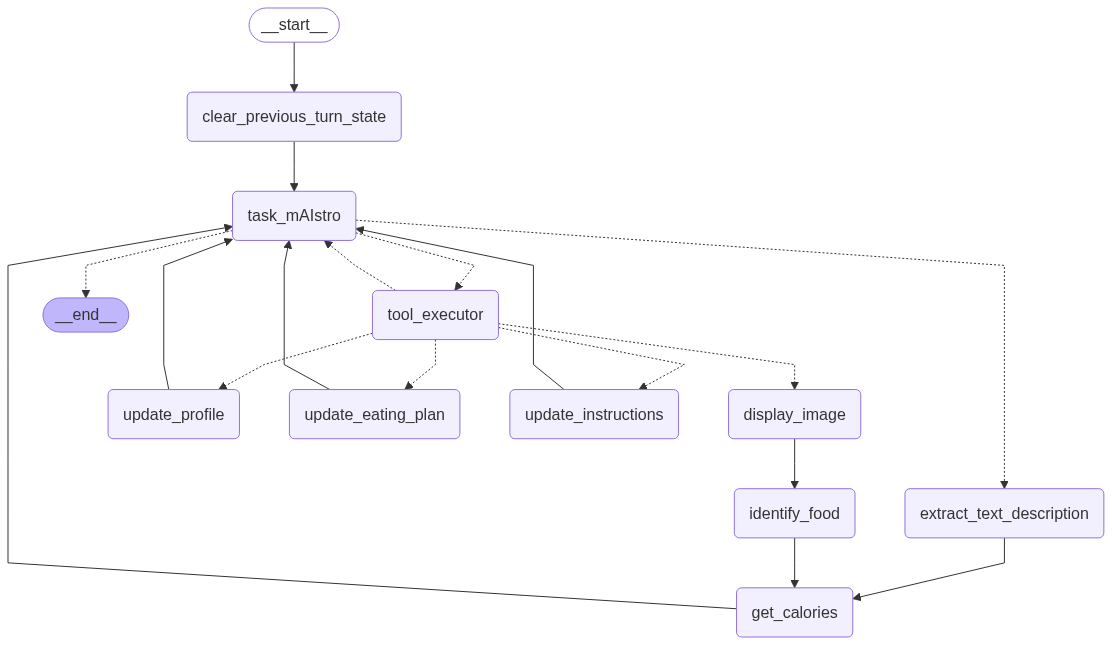

In [10]:
############################## Original pipeline ###################################
# # Conditional edge
# ReturnType = Union[type(END), Literal[
#     "update_eating_plan", "update_instructions", "update_profile", "get_image_path", "extract_text_description"
# ]]

# def route_after_task_mAIstro(state: MessagesState, config: RunnableConfig, store: BaseStore) -> ReturnType:
#     print("✅ route_after_task_mAIstro is running.")
#     last_message = state["messages"][-1]
#     print(f"🧪 last_message type: {type(last_message)}")
#     print(f"🧪 last_message content: {getattr(last_message, 'content', '')}")


#     # 1. Check for tool calls
#     if hasattr(last_message, "tool_calls") and last_message.tool_calls:
#         for tool_call in last_message.tool_calls:
#             tool_name = tool_call.get("name")
#             print(f"🔧 Tool call detected from task_mAIstro: {tool_name}")

#             if tool_name == "UpdateMemory":
#                  update_type = tool_call.get("args", {}).get("update_type")
#                  print(f"🔧 UpdateMemory tool call detected with type: {update_type}. Routing to update_{update_type}.")
#                  if update_type == "user":
#                      return "update_profile"
#                  elif update_type == "eating_plan":
#                      return "update_eating_plan"
#                  elif update_type == "instructions":
#                      return "update_instructions"
#                  else:
#                      print(f"⚠️ Unknown UpdateMemory type: {update_type}. Routing to END.")
#                      return END

#             # elif tool_name == get_image_path.__name__:
#             elif tool_name == "get_image_path":
#                  print(f"🔧 {get_image_path} tool call detected. Routing to {get_image_path}.")
#                  return "get_image_path"

#         print(f"⚠️ Tool calls found from task_mAIstro, but none matched a route. Checking for text food query signal.")

#     # 2. Check for AI message that includes [TEXT_FOOD_QUERY]
#     if isinstance(last_message, AIMessage) and "[TEXT_FOOD_QUERY]" in last_message.content:
#         print("💬 Detected [TEXT_FOOD_QUERY] signal. Routing to extract_text_description.")
#         return "extract_text_description"

#     # Check for the specific text food query signal in the AI message content
#     # if hasattr(last_message, "content") and "[TEXT_FOOD_QUERY]" in last_message.content:
#     #      print("💬 Detected [TEXT_FOOD_QUERY] signal. Routing to extract_text_description.")
#     #      return "extract_text_description"
#     if isinstance(last_message, HumanMessage) and isinstance(last_message.content, str):
#       print("🟡 Pure text input detected from user — assuming it's a food description.")
#       return "extract_text_description"


#     print("✅ No tool call or specific signal detected after task_mAIstro. Ending graph.")
#     return END


# # --- Graph Definition ---
# workflow = StateGraph(MessagesState)

# workflow.add_node("task_mAIstro", task_mAIstro)
# workflow.add_node("extract_text_description", extract_text_description) # Add the new node

# # Image pipeline nodes
# workflow.add_node("get_image_path", ToolNode([get_image_path]))
# workflow.add_node("display_image", display_image)
# workflow.add_node("identify_food", identify_food)
# workflow.add_node("get_calories", get_calories)

# # Memory update nodes
# workflow.add_node("update_profile", update_profile)
# workflow.add_node("update_eating_plan", update_eating_plan)
# workflow.add_node("update_instructions", update_instructions)

# # Initial entry point
# workflow.add_edge(START, "task_mAIstro")

# # Conditional edge FROM task_mAIstro
# workflow.add_conditional_edges(
#     "task_mAIstro",
#     route_after_task_mAIstro,
#     {
#         "update_profile": "update_profile",
#         "update_eating_plan": "update_eating_plan",
#         "update_instructions": "update_instructions",
#         "get_image_path": "get_image_path",
#         "extract_text_description": "extract_text_description", # Route text food query signal here
#         END: END,
#     }
# )

# # Edge from text extraction to get_calories
# # After extracting the text description into the state, proceed to get_calories
# # workflow.add_edge("extract_text_description", "get_calories")
# # Define a simple router that always returns "get_calories"
# def route_to_get_calories(state: MessagesState) -> Literal["get_calories"]:
#     print("➡️ Routing from extract_text_description to get_calories")
#     return "get_calories"

# # Add a conditional edge from extract_text_description using the simple router
# workflow.add_conditional_edges(
#     "extract_text_description",
#     route_to_get_calories,
#     {"get_calories": "get_calories"}
# )



# # Edges FROM tool execution nodes back TO task_mAIstro
# # These edges ensure the results are passed back for task_mAIstro to synthesize a response.
# workflow.add_edge("get_calories", "task_mAIstro") # Route calorie result back
# workflow.add_edge("update_eating_plan", "task_mAIstro")
# workflow.add_edge("update_profile", "task_mAIstro")
# workflow.add_edge("update_instructions", "task_mAIstro") # Assuming this is update_instructions

# # Image pipeline edges
# workflow.add_edge("get_image_path", "display_image")
# workflow.add_edge("display_image", "identify_food")
# workflow.add_edge("identify_food", "get_calories") # After identifying image food, call get_calories


# # Store and compile
# across_thread_memory = InMemoryStore()
# within_thread_memory = MemorySaver()
# graph = workflow.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# # View
# display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

############################## End of original pipeline ###################################


# # Conditional edge
# ReturnType = Union[type(END), Literal[
#     "update_eating_plan", "update_instructions", "update_profile", "get_image_path", "extract_text_description", "execute_all_tools"
# ]]

# def route_after_task_mAIstro(state: MessagesState, config: RunnableConfig, store: BaseStore) -> ReturnType:
#     print("✅ route_after_task_mAIstro is running.")
#     last_message = state["messages"][-1]
#     print(f"🧪 last_message type: {type(last_message)}")
#     print(f"🧪 last_message content: {getattr(last_message, 'content', '')}")

#     if hasattr(last_message, "tool_calls") and last_message.tool_calls:
#         print(f"🔧 Detected multiple tool calls from task_mAIstro. Routing to execute_all_tools.")
#         return "execute_all_tools"

#     if isinstance(last_message, AIMessage) and "[TEXT_FOOD_QUERY]" in last_message.content:
#         print("💬 Detected [TEXT_FOOD_QUERY] signal. Routing to extract_text_description.")
#         return "extract_text_description"

#     if isinstance(last_message, HumanMessage) and isinstance(last_message.content, str):
#         print("🟡 Pure text input detected from user — assuming it's a food description.")
#         return "extract_text_description"

#     print("✅ No tool call or specific signal detected after task_mAIstro. Ending graph.")
#     return END


# def execute_all_tools(state: MessagesState, config: RunnableConfig, store: BaseStore):
#     last_msg = state["messages"][-1]
#     tool_messages = []
#     image_requested = False

#     for call in last_msg.tool_calls:
#         tool_name = call["name"]
#         tool_id = call["id"]
#         args = call.get("args", {})

#         if tool_name == "get_image_path":
#             tool_output = get_image_path.invoke({})
#             image_path = tool_output.get("img_path", "unknown.jpg")
#             tool_messages.append(
#                 ToolMessage(content=f"Image received: {image_path}", tool_call_id=tool_id)
#             )
#             state["img_path"] = image_path
#             state["img_base64"] = None  # Simulate for identify_food
#             image_requested = True

#         elif tool_name == "UpdateMemory":
#             update_type = args.get("update_type", "unknown")
#             if update_type == "user":
#                 state = update_profile(state, config, store)
#             elif update_type == "eating_plan":
#                 state = update_eating_plan(state, config, store)
#             elif update_type == "instructions":
#                 state = update_instructions(state, config, store)
#             tool_messages.append(
#                 ToolMessage(content=f"Memory updated: {update_type}", tool_call_id=tool_id)
#             )

#         elif tool_name == "get_calories":
#             tool_output = get_calories(state)
#             calories_msg = tool_output["messages"][0].content
#             tool_messages.append(
#                 ToolMessage(content=calories_msg, tool_call_id=tool_id)
#             )

#         else:
#             tool_messages.append(
#                 ToolMessage(content=f"Tool '{tool_name}' is not implemented.", tool_call_id=tool_id)
#             )

#     # return {"next": "display_image" if image_requested else "task_mAIstro", **state, "messages": tool_messages}
#     if image_requested:
#         return {**state, "messages": tool_messages, "next": "display_image"}
#     else:
#         return {**state, "messages": tool_messages, "next": "task_mAIstro"}


# # --- Graph Definition ---
# workflow = StateGraph(MessagesState)

# workflow.add_node("task_mAIstro", task_mAIstro)
# workflow.add_node("extract_text_description", extract_text_description)
# workflow.add_node("get_image_path", ToolNode([get_image_path]))
# workflow.add_node("display_image", display_image)
# # workflow.add_node("identify_food", identify_food)
# workflow.add_node("identify_food", identify_food(llm))
# workflow.add_node("get_calories", get_calories)
# workflow.add_node("update_profile", update_profile)
# workflow.add_node("update_eating_plan", update_eating_plan)
# workflow.add_node("update_instructions", update_instructions)
# workflow.add_node("execute_all_tools", execute_all_tools)

# workflow.add_edge(START, "task_mAIstro")
# workflow.add_conditional_edges(
#     "task_mAIstro",
#     route_after_task_mAIstro,
#     {
#         "update_profile": "update_profile",
#         "update_eating_plan": "update_eating_plan",
#         "update_instructions": "update_instructions",
#         "get_image_path": "get_image_path",
#         "extract_text_description": "extract_text_description",
#         "execute_all_tools": "execute_all_tools",
#         END: END,
#     }
# )

# workflow.add_conditional_edges(
#     "extract_text_description",
#     lambda _: "get_calories",
#     {"get_calories": "get_calories"}
# )

# workflow.add_edge("get_calories", "task_mAIstro")
# workflow.add_edge("update_eating_plan", "task_mAIstro")
# workflow.add_edge("update_profile", "task_mAIstro")
# workflow.add_edge("update_instructions", "task_mAIstro")
# workflow.add_edge("get_image_path", "display_image")
# workflow.add_edge("display_image", "identify_food")
# workflow.add_edge("identify_food", "get_calories")
# workflow.add_edge("execute_all_tools", "task_mAIstro")
# workflow.add_edge("execute_all_tools", "display_image")

# across_thread_memory = InMemoryStore()
# within_thread_memory = MemorySaver()
# graph = workflow.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

# # Conditional edge after the ToolNode (or task_mAIstro if no tools were called)
# ReturnType = Union[type(END), Literal[
#     "update_eating_plan", "update_instructions", "update_profile", "get_image_path", "extract_text_description",
#     "display_image", "identify_food", "get_calories" # Include image pipeline nodes
# ]]

# def route_after_tools_or_task(state: MessagesState, config: RunnableConfig, store: BaseStore) -> ReturnType:
#     print("✅ route_after_tools_or_task is running.")
#     last_message = state["messages"][-1]
#     print(f"🧪 last_message type: {type(last_message)}")
#     print(f"🧪 last_message content: {getattr(last_message, 'content', 'N/A')}")
#     print(f"🧪 last_message tool_calls: {getattr(last_message, 'tool_calls', 'N/A')}")

#     # 1. Check if the last message was from task_mAIstro and contained tool calls
#     # If task_mAIstro returned tool calls, LangGraph's ToolNode will run next and add ToolMessages.
#     # The routing function will then be called AFTER the ToolMessages are added.
#     # So, we need to check the ToolMessages for indications of what happened.

#     # Check for ToolMessages in the state to see what tools were executed
#     executed_tool_names = set()
#     for message in reversed(state["messages"]):
#         if isinstance(message, ToolMessage):
#              # Find the original AI message that triggered this ToolMessage
#              # This is a bit indirect, but we can look for tool_call_id matches
#              original_ai_message = None
#              # Search backwards for the AI message with the corresponding tool_call_id
#              for prev_msg in reversed(state["messages"][:-1]):
#                  if hasattr(prev_msg, 'tool_calls') and prev_msg.tool_calls:
#                      for tc in prev_msg.tool_calls:
#                          if tc['id'] == message.tool_call_id:
#                              # We found the original tool call from the AI message
#                              executed_tool_names.add(tc['name'])
#                              original_ai_message = prev_msg
#                              break # Found the original AI message for this ToolMessage
#                  if original_ai_message:
#                      break # Found the original AI message, stop searching for this ToolMessage
#         # Stop searching backwards once we hit a HumanMessage or the start
#         if isinstance(message, HumanMessage):
#              break

#     print(f"🔧 Executed tool names detected: {executed_tool_names}")

#     # 2. Routing based on executed tools or signals

#     # If get_image_path was executed, proceed with the image pipeline
#     if "get_image_path" in executed_tool_names:
#         print("🖼️ get_image_path was executed. Routing to display_image.")
#         return "display_image"

#     # If any of the update tools were executed, route back to task_mAIstro for synthesis
#     # The ToolNode will have executed the correct update_* function.
#     # We check if any of the update tool names are in the executed set.
#     update_tool_names = {"update_profile", "update_eating_plan", "update_instructions"}
#     if executed_tool_names.intersection(update_tool_names):
#         print("💾 An update tool was executed. Routing back to task_mAIstro for response synthesis.")
#         return "task_mAIstro"


#     # If the AI message included the [TEXT_FOOD_QUERY] signal, route to extraction
#     # This case happens if task_mAIstro generated this signal *instead* of a tool call.
#     if isinstance(last_message, AIMessage) and "[TEXT_FOOD_QUERY]" in last_message.content:
#         print("💬 Detected [TEXT_FOOD_QUERY] signal. Routing to extract_text_description.")
#         return "extract_text_description"

#     # If the last message is a HumanMessage with content (implies initial input or follow-up without tool call)
#     # and no tools were executed by the previous step (handled above).
#     # This should ideally route to task_mAIstro for initial processing, but the START edge handles that.
#     # This check might be redundant or indicate an unhandled case.
#     # Let's primarily rely on detecting tool calls or the specific signal.
#     if isinstance(last_message, HumanMessage) and isinstance(last_message.content, str) and not executed_tool_names:
#         # If a HumanMessage reaches here, it might be the first message (handled by START->task_mAIstro)
#         # or a message after task_mAIstro processed something without tools and then rerouted to this node.
#         # In the latter case, the graph should probably end or loop back to task_mAIstro for a non-tool response.
#         # The current structure implicitly ends if no route is matched.
#         # For robustness, if a HumanMessage somehow ends up here and no tools were executed,
#         # we might want to explicitly route back to task_mAIstro or END.
#         # Given the graph structure, if a HumanMessage is the last message, it means
#         # task_mAIstro was the previous node *and* it did not generate a tool call
#         # or the [TEXT_FOOD_QUERY] signal. This state shouldn't typically happen
#         # if task_mAIstro always routes either to tools, extraction, or END.
#         # Let's keep the explicit check for the signal and executed tools as primary.
#         print("🟡 Received HumanMessage after processing, no tools executed. Ending graph.")
#         return END # Or maybe "task_mAIstro" if we want it to try generating a response? Let's END for now.


#     # If none of the above, end the graph (e.g., a final AI response from task_mAIstro that didn't require tools)
#     print("✅ No specific action needed after tools or task. Ending graph.")
#     return END


# # --- Graph Definition ---
# workflow = StateGraph(MessagesState)

# workflow.add_node("task_mAIstro", task_mAIstro)
# workflow.add_node("extract_text_description", extract_text_description)

# # Image pipeline nodes
# workflow.add_node("get_image_path", ToolNode([get_image_path])) # Keep as ToolNode
# workflow.add_node("display_image", display_image)
# workflow.add_node("identify_food", identify_food(llm)) # Assuming identify_food needs the LLM
# workflow.add_node("get_calories", get_calories)

# # Memory update nodes
# workflow.add_node("update_profile", update_profile)
# workflow.add_node("update_eating_plan", update_eating_plan)
# workflow.add_node("update_instructions", update_instructions)

# # The ToolNode for executing tools called by task_mAIstro
# # This node should execute the actual functions or tools corresponding to the LLM's calls.
# # The LLM in task_mAIstro is bound to `UpdateMemory` (a schema) and `get_image_path` (a tool).
# # When the LLM calls `UpdateMemory`, LangGraph's ToolNode mechanism expects to find a tool
# # named "UpdateMemory" to execute.
# # HOWEVER, the node `task_maistro_tools` *should* execute the functions that *implement*
# # the memory updates based on the `update_type` argument.
# # Let's redefine `task_maistro_tools` to be a node that routes internally based on tool calls.
# # A better approach is to have task_mAIstro output a specific signal or directly route
# # to the appropriate node (update_profile, update_eating_plan, update_instructions, get_image_path)
# # based on the LLM's intent.

# # Let's revert to the previous routing logic but fix the `ToolNode` initialization.
# # The `ToolNode` should execute the tools that task_mAIstro might call directly.
# # task_mAIstro is bound to `UpdateMemory` (schema) and `get_image_path` (tool).
# # The ToolNode will execute the *actual* tool function `get_image_path` if called.
# # But it cannot execute `UpdateMemory` directly as it's not a function.

# # A cleaner approach: task_mAIstro outputs tool calls. The *router* checks these tool calls.
# # If it sees an `UpdateMemory` call, it routes to a node that handles dispatching
# # to the correct update function based on the `update_type`.
# # If it sees a `get_image_path` call, it routes to `get_image_path`.

# # Let's define the router `route_after_task_mAIstro` to check for tool calls
# # and route to the specific node (`update_profile`, `update_eating_plan`, `update_instructions`, `get_image_path`)

# # Conditional edge FROM task_mAIstro
# # Redefine the router based on the LLM's output (before ToolNode execution)
# ReturnType_TaskRouter = Union[type(END), Literal[
#     "update_eating_plan", "update_instructions", "update_profile", "get_image_path", "extract_text_description"
# ]]

# def route_after_task_mAIstro(state: MessagesState) -> ReturnType_TaskRouter:
#     print("✅ route_after_task_mAIstro is running.")
#     last_message = state["messages"][-1]
#     print(f"🧪 last_message type: {type(last_message)}")
#     print(f"🧪 last_message content: {getattr(last_message, 'content', 'N/A')}")
#     print(f"🧪 last_message tool_calls: {getattr(last_message, 'tool_calls', 'N/A')}")

#     # Check for tool calls made by task_mAIstro
#     if hasattr(last_message, "tool_calls") and last_message.tool_calls:
#         # Assuming task_mAIstro might make multiple parallel calls,
#         # prioritize image processing if requested, otherwise handle memory updates.
#         # Or, we can handle parallel calls by routing to a dispatcher node.
#         # Let's route to a dispatcher node that handles parallel execution of specific tools.
#         # However, the original code had separate nodes for each update type and get_image_path.
#         # Let's stick to routing to individual nodes first.

#         # Check for specific tool calls
#         for tool_call in last_message.tool_calls:
#              tool_name = tool_call.get("name")
#              if tool_name == "get_image_path":
#                   print("🖼️ get_image_path tool call detected. Routing to get_image_path node.")
#                   return "get_image_path"
#              elif tool_name == "UpdateMemory":
#                   update_type = tool_call.get("args", {}).get("update_type")
#                   print(f"💾 UpdateMemory tool call detected with type: {update_type}. Routing to update_{update_type}.")
#                   if update_type == "user":
#                       return "update_profile"
#                   elif update_type == "eating_plan":
#                       return "update_eating_plan"
#                   elif update_type == "instructions":
#                       return "update_instructions"
#                   else:
#                       print(f"⚠️ Unknown UpdateMemory type: {update_type}. Cannot route.")
#                       # What happens if a tool call is made but doesn't match a route? Graph ends? Error?
#                       # Let's assume it should fall through or raise an error if not handled.
#                       # For now, let's just continue checking other possibilities.
#                   pass # Continue checking other tool calls or signals

#         # If tool calls were made but none matched specific routes, this is an issue.
#         # Let's add a log and potentially route to END or back to task_mAIstro.
#         print("⚠️ Tool calls found but no specific route matched. Check ToolNode binding or router logic.")
#         # If we wanted to execute ANY called tool via a ToolNode here, we would route to it.
#         # But the current ToolNode setup only includes get_image_path and UpdateMemory (which caused the error).
#         # The individual update_* functions are separate nodes.
#         # The error was in creating a ToolNode with UpdateMemory (TypedDict).
#         # The strategy should be: task_mAIstro -> Router (check tool calls/signal) -> Specific Tool Node (get_image_path) OR Specific Update Node (update_*) OR Extraction Node OR END.

#         # If we are here, tool calls were detected, but no matching route was found.
#         # This implies an unhandled tool call from task_mAIstro. This needs debugging.
#         # For now, let's not route based on unmatched tool calls and check the next conditions.
#         pass


#     # Check for AI message that includes [TEXT_FOOD_QUERY]
#     if isinstance(last_message, AIMessage) and "[TEXT_FOOD_QUERY]" in last_message.content:
#         print("💬 Detected [TEXT_FOOD_QUERY] signal. Routing to extract_text_description.")
#         return "extract_text_description"

#     # If the last message is a HumanMessage with content (implies initial input or follow-up without tool call)
#     # This case should usually only happen at the START of the graph, which routes to task_mAIstro.
#     # If a HumanMessage appears *after* task_mAIstro, it suggests task_mAIstro returned a HumanMessage
#     # which is not the expected behavior (it should return AIMessage with tool calls, signal, or final response).
#     # However, if task_mAIstro was somehow skipped or failed, a HumanMessage might appear here.
#     # Based on the commented-out code, it seems a HumanMessage might also trigger extract_text_description.
#     # Let's add this back if pure text input should always go to extraction initially.
#     # BUT, the prompt for task_mAIstro says it should handle text descriptions and output [TEXT_FOOD_QUERY].
#     # So, if a HumanMessage is the last message here, it means task_mAIstro DID NOT process it.
#     # This might be an error in the flow.
#     # Let's assume task_mAIstro *always* processes the HumanMessage and returns an AIMessage.
#     # Thus, if the last message is HumanMessage, something is wrong with the preceding node (task_mAIstro).
#     # Removing the HumanMessage check here based on the logic flow.

#     print("✅ No tool call or specific signal detected after task_mAIstro. Ending graph.")
#     return END


# workflow = StateGraph(MessagesState)

# workflow.add_node("task_mAIstro", task_mAIstro)
# workflow.add_node("extract_text_description", extract_text_description)

# # Image pipeline nodes
# # get_image_path is a ToolNode because the *LLM* calls a tool named get_image_path
# workflow.add_node("get_image_path", ToolNode([get_image_path])) # Correct: uses the get_image_path tool instance
# workflow.add_node("display_image", display_image)
# workflow.add_node("identify_food", identify_food(llm)) # Pass LLM if needed
# workflow.add_node("get_calories", get_calories)

# # Memory update nodes
# # These are regular nodes that are called by the graph based on routing decisions,
# # NOT by a ToolNode executing LLM calls directly.
# workflow.add_node("update_profile", update_profile)
# workflow.add_node("update_eating_plan", update_eating_plan)
# workflow.add_node("update_instructions", update_instructions)


# # Initial entry point
# workflow.add_edge(START, "task_mAIstro")

# # Conditional edge FROM task_mAIstro to route based on its output (tool calls or signal)
# workflow.add_conditional_edges(
#     "task_mAIstro",
#     route_after_task_mAIstro,
#     {
#         "update_profile": "update_profile", # Route directly to update nodes if called by LLM
#         "update_eating_plan": "update_eating_plan",
#         "update_instructions": "update_instructions",
#         "get_image_path": "get_image_path", # Route directly to get_image_path ToolNode if called by LLM
#         "extract_text_description": "extract_text_description", # Route to extraction node if signal detected
#         END: END, # End if no specific action is needed
#     }
# )

# # Edge from text extraction to get_calories
# workflow.add_edge("extract_text_description", "get_calories")

# # Edges within the image pipeline
# workflow.add_edge("get_image_path", "display_image") # After getting image path, display it
# workflow.add_edge("display_image", "identify_food") # After displaying, identify food
# workflow.add_edge("identify_food", "get_calories") # After identifying, get calories


# # Edges from nodes that produce results back to task_mAIstro for synthesis
# # These nodes have completed their specific task and the result (e.g., calorie info, update confirmation)
# # is now in the state. task_mAIstro needs to process this result and generate a user-facing response.
# workflow.add_edge("get_calories", "task_mAIstro")
# workflow.add_edge("update_eating_plan", "task_mAIstro")
# workflow.add_edge("update_profile", "task_mAIstro")
# workflow.add_edge("update_instructions", "task_mAIstro")


# # Store and compile
# across_thread_memory = InMemoryStore()
# within_thread_memory = MemorySaver()
# graph = workflow.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# # View the updated graph
# display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

# ##################################### CHAT GPT #################################
# --- Graph Definition ---
# from langgraph.graph import StateGraph, START, END
# from langgraph.checkpoint.memory import MemorySaver
# from langgraph.store.memory import InMemoryStore
# from langchain_core.runnables import RunnableConfig
# from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
# from typing import Union, Literal
# from IPython.display import display, Image

# ReturnType = Union[type(END), Literal[
#     "update_eating_plan", "update_instructions", "update_profile", "get_image_path", "extract_text_description",
#     "display_image", "identify_food", "get_calories"
# ]]

# def route_after_task_mAIstro(state):
#     print("✅ route_after_task_mAIstro is running.")
#     last_message = state["messages"][-1]
#     print(f"🧪 last_message type: {type(last_message)}")
#     print(f"🧪 last_message content: {getattr(last_message, 'content', 'N/A')}")
#     print(f"🧪 last_message tool_calls: {getattr(last_message, 'tool_calls', 'N/A')}")

#     if hasattr(last_message, "tool_calls") and last_message.tool_calls:
#         executed_tool_names = set(tc.get("name") for tc in last_message.tool_calls)
#         print(f"🔧 Tool calls detected: {executed_tool_names}")

#         # Priority order to preserve graph logic
#         if "get_image_path" in executed_tool_names:
#             return "get_image_path"

#         for tool_call in last_message.tool_calls:
#             if tool_call.get("name") == "UpdateMemory":
#                 update_type = tool_call.get("args", {}).get("update_type")
#                 if update_type == "user":
#                     return "update_profile"
#                 elif update_type == "eating_plan":
#                     return "update_eating_plan"
#                 elif update_type == "instructions":
#                     return "update_instructions"

#     if isinstance(last_message, AIMessage) and "[TEXT_FOOD_QUERY]" in last_message.content:
#         return "extract_text_description"

#     return END
############################# NEW VERSION 6/3 13:06 ############################
# --- New Tool Dispatch Router ---
# This router examines the *original* tool calls from task_mAIstro's AIMessage
# and decides which *specific node* to route to *after* the main ToolNode executes.
# However, the LangGraph ToolNode automatically executes the tools and adds ToolMessages.
# So the router *after* the ToolNode needs to check the ToolMessages.

# Let's stick to the router *after* the ToolNode, but make it smarter.
# It needs to know which tools ran and decide the next step based on their *type*.

# --- Define the main Tool Execution Node ---
# This ToolNode should be bound to ALL tools that task_mAIstro might call.
# task_mAIstro calls `UpdateMemory` (a TypedDict schema) and `get_image_path` (a Runnable tool).
# A ToolNode cannot directly execute a TypedDict. We need a function that represents UpdateMemory.

# Let's create a simple placeholder tool/function for UpdateMemory that the ToolNode can execute.
# Its only job is to signal that an UpdateMemory call was intended and pass the args.
def process_update_memory_tool_call(update_type: Literal['user', 'eating_plan', 'instructions']):
    """Placeholder tool to signal UpdateMemory intent and pass args."""
    # This function doesn't actually perform the update.
    # The routing logic *after* the ToolNode will read the original tool call args
    # and route to the correct update_* node.
    print(f"Placeholder tool executed: Processing UpdateMemory tool call for type: {update_type}")
    return f"Processing UpdateMemory tool call for type: {update_type}"

# Make the placeholder function a tool runnable
process_update_memory_tool = RunnableLambda(process_update_memory_tool_call).with_config(run_name="UpdateMemory")
# We need it to have the same name as the tool called by the LLM
process_update_memory_tool.name = "UpdateMemory" # Ensure the name matches the LLM's call

# Now, the main ToolNode will be bound to both the actual get_image_path tool
# AND this placeholder tool for UpdateMemory.
# When task_mAIstro calls `{"name": "UpdateMemory", "args": {"update_type": "..."}}`,
# LangGraph will execute `process_update_memory_tool`.
# The router *after* this ToolNode will then see the result from this placeholder
# (or the original tool call in the state) and route to the correct `update_*` node.
# --- New Router after the ToolNode ---
# This router examines the *original tool calls* that were just executed by the ToolNode.
# It decides the subsequent graph flow based on the *types* of tools executed.
# ReturnType_ToolExecutorRouter = Union[type(END), Literal[
#     "display_image", # Start image pipeline
#     "dispatch_memory_update", # Route to a dispatcher for memory updates
#     "task_mAIstro" # Go back for synthesis (e.g., if only memory update occurred or after image pipeline)
# ]]

# def route_after_tool_executor(state: MessagesState) -> ReturnType_ToolExecutorRouter:
#     print("\n--- Running route_after_tool_executor ---")
#     print(f"State at start: {state}")
#     print("-----------------------------------------\n")

#     # Look at the last message, which should be an AIMessage from the ToolNode
#     # containing ToolMessages for each tool that was executed.
#     last_message = state["messages"][-1]
#     print(f"🧪 last_message type: {type(last_message)}")
#     print(f"🧪 last_message content: {getattr(last_message, 'content', 'N/A')}")
#     print(f"🧪 last_message tool_messages: {getattr(last_message, 'tool_messages', 'N/A')}")


#     # Find the original tool calls from the AIMessage that the ToolNode processed
#     original_tool_calls = None
#     # Search backwards for the AIMessage right before the ToolMessages added by the ToolNode
#     for msg in reversed(state['messages'][:-1]):
#         if isinstance(msg, AIMessage) and hasattr(msg, 'tool_calls') and msg.tool_calls:
#              original_tool_calls = msg.tool_calls
#              break

#     if not original_tool_calls:
#          print("⚠️ Could not find original tool calls from task_mAIstro in state.")
#          # If we can't find the original tool calls, something is wrong. Route back or end.
#          return "task_mAIstro" # Route back to task_mAIstro to see if it can recover or synthesize.

#     print(f"🔍 Found original tool calls: {original_tool_calls}")

#     # Check which *types* of actions were requested by the original tool calls
#     needs_image_pipeline = any(tc.get("name") == "get_image_path" for tc in original_tool_calls)
#     needs_memory_update = any(tc.get("name") == "UpdateMemory" for tc in original_tool_calls)

#     print(f"Intent flags: needs_image_pipeline={needs_image_pipeline}, needs_memory_update={needs_memory_update}")

#     # Routing logic: Prioritize the image pipeline if requested, then handle memory updates.
#     # After either, route back to task_mAIstro for synthesis.

#     if needs_image_pipeline:
#          print("🖼️ Image pipeline needed. Routing to display_image.")
#          return "display_image"

#     if needs_memory_update:
#          print("💾 Memory update(s) needed. Routing to dispatch_memory_update.")
#          return "dispatch_memory_update"

#     # If no specific pipeline or update was triggered by the tool calls,
#     # route back to task_mAIstro to synthesize the ToolMessage results into a response.
#     # This handles cases where the tool execution might have failed or didn't fit the patterns above.
#     print("➡️ No specific pipeline or update triggered by tool calls. Routing back to task_mAIstro for synthesis.")
#     return "task_mAIstro"


# --- New Node to Dispatch Memory Updates ---
# This node receives the state *after* the ToolNode (which executed the UpdateMemory placeholder).
# It reads the original tool calls and routes to the correct specific update_* node.
ReturnType_MemoryDispatcher = Union[type(END), Literal[
    "update_profile",
    "update_eating_plan",
    "update_instructions",
    "task_mAIstro" # After updates, go back for synthesis
]]

def dispatch_memory_update(state: MessagesState) -> ReturnType_MemoryDispatcher:
    print("\n--- Running dispatch_memory_update ---")
    print(f"State at start: {state}")
    print("-----------------------------------------\n")

    # Find the original tool calls related to UpdateMemory from task_mAIstro's AIMessage
    original_tool_calls = None
    # Search backwards for the AIMessage right before the ToolMessages
    for msg in reversed(state['messages'][:-1]):
        if isinstance(msg, AIMessage) and hasattr(msg, 'tool_calls') and msg.tool_calls:
             original_tool_calls = msg.tool_calls
             break

    if not original_tool_calls:
         print("⚠️ Could not find original tool calls in state for dispatch_memory_update.")
         return "task_mAIstro" # Route back to synthesis if context is lost

    print(f"🔍 Found original tool calls for dispatch: {original_tool_calls}")

    # Find the first UpdateMemory tool call to dispatch
    for tc in original_tool_calls:
        if tc.get("name") == "UpdateMemory":
            update_type = tc.get("args", {}).get("update_type")
            print(f"Dispatching UpdateMemory call for type: {update_type}")
            if update_type == "user":
                # We need to somehow *trigger* the update_profile node.
                # We can't just return "update_profile" directly here if other
                # update types might also be pending from parallel calls.
                # A simple approach is to handle only one type per node execution
                # or to pass flags.

                # Let's simplify: Assume dispatch_memory_update handles *one* update
                # type and then routes back to itself or a decision node if more are pending.
                # Or, even simpler: The router *after* the ToolNode checks for *which*
                # specific update types were requested and routes accordingly.

                # Let's revise the routing after the ToolNode again. Instead of
                # a single "dispatch_memory_update", it can route directly to
                # update_profile, update_eating_plan, or update_instructions
                # if those *types* of calls were present in the original AIMessage.

                pass # Re-evaluating routing after ToolNode

    # Let's go back to refining `route_after_tool_executor` to route directly
    # to the specific update nodes or the image pipeline.

    print("✅ Dispatch completed or no UpdateMemory call found. Routing back to task_mAIstro for synthesis.")
    return "task_mAIstro" # After attempting dispatch, always go back for synthesis


# --- Refined Router after the ToolNode (Option 3 refined) ---
# This router examines the *original tool calls* from task_mAIstro's AIMessage
# (which were just processed by the main ToolNode) and decides the next step.
# It will prioritize the image pipeline, then memory updates, then synthesis.
ReturnType_ToolExecutorRouter_V2 = Union[type(END), Literal[
    "display_image", # Start image pipeline
    "update_profile", # Start specific update logic
    "update_eating_plan",
    "update_instructions",
    "task_mAIstro" # Go back for synthesis
]]

def route_after_tool_executor(state: MessagesState) -> ReturnType_ToolExecutorRouter_V2:
    print("\n--- Running route_after_tool_executor ---")
    print(f"State at start: {state}")
    print("-----------------------------------------\n")

    # Find the original tool calls from the AIMessage that the ToolNode processed
    original_tool_calls = None
    # Search backwards for the AIMessage right before the ToolMessages added by the ToolNode
    # We need to look at the AIMessage that *triggered* the ToolNode execution.
    # This AIMessage is typically the result of the preceding `task_mAIstro` node.
    search_messages = list(reversed(state['messages']))
    # Find the block of ToolMessages and the preceding AIMessage
    ai_msg_before_tools = None
    tool_msgs_block = []
    for msg in search_messages:
        if isinstance(msg, ToolMessage):
            tool_msgs_block.append(msg)
        elif isinstance(msg, AIMessage) and tool_msgs_block: # Found the AI message just before the ToolMessages
            ai_msg_before_tools = msg
            break
        elif isinstance(msg, HumanMessage): # Stop searching if we hit a HumanMessage without finding the AI+ToolMessage block
             break

    if ai_msg_before_tools and hasattr(ai_msg_before_tools, 'tool_calls') and ai_msg_before_tools.tool_calls:
         original_tool_calls = ai_msg_before_tools.tool_calls
    else:
         print("⚠️ Could not find original tool calls from preceding AIMessage.")
         # If we can't find the original tool calls, something is wrong. Route back or end.
         return "task_mAIstro" # Route back to task_mAIstro to see if it can recover or synthesize.


    print(f"🔍 Found original tool calls from preceding AIMessage: {original_tool_calls}")

    # Check which *types* of actions were requested by the original tool calls
    # Prioritize get_image_path first
    if any(tc.get("name") == "get_image_path" for tc in original_tool_calls):
         print("🖼️ get_image_path was requested. Routing to display_image.")
         return "display_image"

    # Then check for UpdateMemory types
    update_needed_type = None
    for tc in original_tool_calls:
         if tc.get("name") == "UpdateMemory":
              update_needed_type = tc.get("args", {}).get("update_type")
              if update_needed_type:
                   print(f"💾 UpdateMemory of type '{update_needed_type}' was requested. Routing.")
                   break # Route to the first detected update type

    if update_needed_type == "user":
         return "update_profile"
    elif update_needed_type == "eating_plan":
         return "update_eating_plan"
    elif update_needed_type == "instructions":
         return "update_instructions"


    # If no specific pipeline or update was triggered by the tool calls that require
    # a specific subsequent node *after* the main ToolNode,
    # route back to task_mAIstro to synthesize the ToolMessage results into a response.
    print("➡️ No specific pipeline or update triggered requiring dedicated node after ToolNode. Routing back to task_mAIstro for synthesis.")
    return "task_mAIstro"

############################# NEW VERSION 6/3 11:30 ############################
ReturnType = Union[type(END), Literal[
    "update_eating_plan", "update_instructions", "update_profile", "get_image_path",
    "extract_text_description", "execute_all_tools" # Include any other potential nodes
]]

def route_after_task_mAIstro(state: MessagesState, config: RunnableConfig, store: BaseStore) -> ReturnType:
    print("✅ route_after_task_mAIstro is running.")
    last_message = state["messages"][-1]
    print(f"🧪 last_message type: {type(last_message)}")
    print(f"🧪 last_message content (first 50 chars): {str(getattr(last_message, 'content', 'N/A'))[:50]}...")
    print(f"🧪 last_message tool_calls: {getattr(last_message, 'tool_calls', 'N/A')}")

    # Prioritize checking for tool calls generated by task_mAIstro
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        print(f"🔧 Detected {len(last_message.tool_calls)} tool call(s) from task_mAIstro.")
        # If you want to handle multiple tool calls in a single node:
        # return "execute_all_tools" # Route to a node that iterates and runs tools
        # If you want to route based on the *first* tool call (simplest):
        first_tool_call = last_message.tool_calls[0]
        tool_name = first_tool_call.get("name")
        print(f"    Processing first tool call: {tool_name}")

        if tool_name == "UpdateMemory":
             update_type = first_tool_call.get("args", {}).get("update_type")
             print(f"    UpdateMemory type: {update_type}. Routing...")
             if update_type == "user": return "update_profile"
             elif update_type == "eating_plan": return "update_eating_plan"
             elif update_type == "instructions": return "update_instructions"
             else: print(f"    ⚠️ Unknown UpdateMemory type: {update_type}. Defaulting to END.")
        elif tool_name == "get_image_path":
             print("    Routing to get_image_path.")
             return "get_image_path"
        # Add conditions for other tools task_mAIstro might call directly

        print("🔧 No matched tool call routes. Checking for text food query signal.")
        # If there were tool calls but none matched a specific route, this might indicate a problem
        # or that the LLM called an unexpected tool. Consider logging a warning.


    # If no tool calls, check for the TEXT_FOOD_QUERY signal
    if isinstance(last_message, AIMessage) and isinstance(last_message.content, str) and last_message.content.startswith("[TEXT_FOOD_QUERY]"):
        print("💬 Detected [TEXT_FOOD_QUERY] signal. Routing to extract_text_description.")
        return "extract_text_description"

    # You might add a fallback here if task_mAIstro sometimes outputs text *without*
    # tool calls or the signal, and that text requires further processing.
    # However, with the clear state, relying primarily on tool calls and the signal is best.


    print("✅ No routing condition met. Ending graph.")
    return END

################################################################################

# workflow = StateGraph(MessagesState)
# workflow.add_node("task_mAIstro", task_mAIstro)
# workflow.add_node("extract_text_description", extract_text_description)
# workflow.add_node("get_image_path", ToolNode([get_image_path]))
# workflow.add_node("display_image", display_image)
# workflow.add_node("identify_food", identify_food(llm))
# workflow.add_node("get_calories", get_calories)
# workflow.add_node("update_profile", update_profile)
# workflow.add_node("update_eating_plan", update_eating_plan)
# workflow.add_node("update_instructions", update_instructions)

# workflow.add_edge(START, "task_mAIstro")
# workflow.add_conditional_edges(
#     "task_mAIstro",
#     route_after_task_mAIstro,
#     {
#         "update_profile": "update_profile",
#         "update_eating_plan": "update_eating_plan",
#         "update_instructions": "update_instructions",
#         "get_image_path": "get_image_path",
#         "extract_text_description": "extract_text_description",
#         END: END,
#     }
# )

# workflow.add_edge("extract_text_description", "get_calories")
# workflow.add_edge("get_image_path", "display_image")
# workflow.add_edge("display_image", "identify_food")
# workflow.add_edge("identify_food", "get_calories")
# workflow.add_edge("get_calories", "task_mAIstro")
# workflow.add_edge("update_eating_plan", "task_mAIstro")
# workflow.add_edge("update_profile", "task_mAIstro")
# workflow.add_edge("update_instructions", "task_mAIstro")

# across_thread_memory = InMemoryStore()
# within_thread_memory = MemorySaver()
# graph = workflow.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

############################ Gemini ###########################################
# Assume all preceding code defining nodes, tools, etc., is present.

# --- New Router after the ToolNode (Revised) ---
# This router examines the ToolMessages added by the ToolNode.
# It decides the *immediate next step* based on the results.
ReturnType_ToolExecutorRouter = Union[type(END), Literal[
    "display_image", # Start image pipeline
    "update_profile", # Start specific update logic
    "update_eating_plan",
    "update_instructions",
    "task_mAIstro" # Go back for synthesis
]]

def route_after_tool_executor(state: MessagesState) -> ReturnType_ToolExecutorRouter:
    print("\n--- Running route_after_tool_executor ---")
    print(f"State at start: {state}")
    print("-----------------------------------------\n")

    # Check the ToolMessages in the state
    tool_messages = [msg for msg in state["messages"] if isinstance(msg, ToolMessage)]

    # Flags to indicate if a pipeline/action is needed *after* this router decides
    needs_image_pipeline = False
    needs_update_profile = False
    needs_update_eating_plan = False
    needs_update_instructions = False

    print(f"Examining {len(tool_messages)} ToolMessages for routing:")
    for tool_msg in reversed(tool_messages): # Look at the most recent ones first
        print(f"  - ToolMessage content: {tool_msg.content[:100]}...")
        # Find the original tool call associated with this ToolMessage
        original_tool_call = None
        # Search backwards in the history for the AIMessage containing this tool_call_id
        # Stop searching once we pass the AIMessage that likely triggered the ToolNode
        search_history = []
        for msg in reversed(state['messages']):
            search_history.append(msg)
            if isinstance(msg, AIMessage): # Found the AI message before the ToolMessages
                 break

        for msg in search_history:
             if isinstance(msg, AIMessage) and hasattr(msg, 'tool_calls') and msg.tool_calls:
                  for tc in msg.tool_calls:
                       if tc['id'] == tool_msg.tool_call_id:
                            original_tool_call = tc
                            break
                  if original_tool_call:
                        break # Found the original tool call


        if original_tool_call:
             tool_name = original_tool_call['name']
             tool_args = original_tool_call.get('args', {})
             print(f"    -> Associated original tool call: {tool_name} with args {tool_args}")

             # Check for the result of get_image_path
             if tool_name == "get_image_path" and "img_path" in tool_msg.content:
                  print("    -> get_image_path executed successfully. Image pipeline needed.")
                  needs_image_pipeline = True

             # Check for the result of UpdateMemory placeholder tool
             # Assuming the placeholder tool returns content like "Processing UpdateMemory tool call for type: ..."
             elif tool_name == "UpdateMemory" and tool_msg.content.startswith("Processing UpdateMemory tool call"):
                  update_type = tool_args.get("update_type")
                  print(f"    -> UpdateMemory tool call processed by ToolNode for type: {update_type}. Specific update logic needed.")
                  if update_type == "user":
                       needs_update_profile = True
                  elif update_type == "eating_plan":
                       needs_update_eating_plan = True
                  elif update_type == "instructions":
                       needs_update_instructions = True

        else:
             print(f"    ⚠️ Could not find original tool call for ToolMessage with ID: {tool_msg.tool_call_id}. Content: {tool_msg.content[:50]}...")
             # This might happen for ToolMessages added by nodes *other* than the main tool_executor ToolNode


    # Routing logic: Decide the *immediate next step*.
    # If both image and updates are needed, which goes first?
    # Let's prioritize the update nodes sequentially, then the image pipeline.
    # This way, the profile is updated before image processing starts.
    # Or, we could prioritize image, then handle updates after get_calories.

    # Let's try prioritizing updates first if any were requested via ToolMessages.
    if needs_update_profile:
         print("💾 User profile update needed. Routing to update_profile.")
         return "update_profile"
    elif needs_update_eating_plan:
         print("💾 Eating plan update needed. Routing to update_eating_plan.")
         return "update_eating_plan"
    elif needs_update_instructions:
         print("💾 Instructions update needed. Routing to update_instructions.")
         return "update_instructions"

    # If no updates were needed or routed, check for image pipeline.
    if needs_image_pipeline:
         print("🖼️ Image pipeline needed. Routing to display_image.")
         return "display_image"


    # If no specific pipeline or update was triggered by the ToolMessages,
    # route back to task_mAIstro to synthesize the ToolMessage results into a response.
    # This also covers cases where tool execution failed or didn't produce expected results.
    print("➡️ No specific pipeline or update triggered by ToolMessages. Routing back to task_mAIstro for synthesis.")
    return "task_mAIstro"

# Define the Clear State Node
def clear_previous_turn_state(state: State):
    """Clears state fields related to processing the previous turn."""
    print("🧹 Clearing previous turn state for new input.")
    # Identify fields that should be reset at the start of a new turn
    fields_to_clear = [
        "text_description",
        "img_path",
        "img_base64",
        "img_interpertation",
        # Add any other fields that should not carry over between distinct user inputs
    ]

    updated_state = state.copy() # Work on a copy to be safe

    for field in fields_to_clear:
        if field in updated_state:
            print(f"    Clearing state field: {field}")
            updated_state[field] = None # Or set to default value like "" or []

    # Important: The incoming HumanMessage is already in state['messages'].
    # We should *not* clear the messages list here, as task_mAIstro needs the history.

    return updated_state # Return the modified state


# # --- Graph Definition (Corrected Edges) ---
# workflow = StateGraph(MessagesState)

# # Add the clear state node
# workflow.add_node("clear_previous_turn_state", clear_previous_turn_state)

# # Add nodes
# workflow.add_node("task_mAIstro", task_mAIstro)
# workflow.add_node("extract_text_description", extract_text_description)

# # Image pipeline nodes (Use modified versions)
# # get_image_path is a ToolNode because the *LLM* calls a tool named get_image_path.
# # The ToolNode executes this specific tool instance.
# workflow.add_node("get_image_path", ToolNode([get_image_path])) # Correct: uses the get_image_path tool instance
# workflow.add_node("display_image", display_image)
# workflow.add_node("identify_food", identify_food) # Pass LLM if needed # identify_food(llm)
# workflow.add_node("get_calories", get_calories)

# # Memory update nodes (These are separate nodes executed based on routing)
# # These nodes contain the logic to interact with the memory store,
# # triggered by the router detecting an "UpdateMemory" tool call intent from task_mAIstro.
# workflow.add_node("update_profile", update_profile)
# workflow.add_node("update_eating_plan", update_eating_plan)
# workflow.add_node("update_instructions", update_instructions)

# # Remove the problematic 'tool_executor' node


# # Define edges

# # # Start -> task_mAIstro (Initial entry point)
# # workflow.add_edge(START, "task_mAIstro")

# # Initial entry point: START -> clear_previous_turn_state -> task_mAIstro
# workflow.add_edge(START, "clear_previous_turn_state")
# workflow.add_edge("clear_previous_turn_state", "task_mAIstro")

# # task_mAIstro -> route_after_task_mAIstro (to decide next step based on AIMessage's tool calls or signal)
# # The router will directly route to the specific node needed (get_image_path ToolNode,
# # extract_text_description node, or one of the update_* nodes)
# workflow.add_conditional_edges(
#     "task_mAIstro",
#     route_after_task_mAIstro,
#     {
#         # Route directly to the appropriate node based on the tool call name
#         "update_profile": "update_profile",
#         "update_eating_plan": "update_eating_plan",
#         "update_instructions": "update_instructions",
#         "get_image_path": "get_image_path", # Route to the ToolNode executing get_image_path
#         "extract_text_description": "extract_text_description", # Route to extraction node if text signal detected
#         # "execute_all_tools": "execute_all_tools", # If you implement a multi-tool execution node
#         END: END, # End if no specific action is needed based on task_mAIstro's output
#     }
# )

# # extract_text_description -> get_calories (Unconditional edge)
# # After extracting text, always proceed to get_calories
# workflow.add_edge("extract_text_description", "get_calories")


# # Nodes that perform actions and return results should route back to task_mAIstro for synthesis
# # This includes ToolNodes that successfully execute tools.
# workflow.add_edge("get_calories", "task_mAIstro")
# workflow.add_edge("update_profile", "task_mAIstro")
# workflow.add_edge("update_eating_plan", "task_mAIstro")
# workflow.add_edge("update_instructions", "task_mAIstro")

# # The get_image_path ToolNode, after successfully getting the image path,
# # should route to the next step in the image pipeline.
# workflow.add_edge("get_image_path", "display_image")


# # Edges within the image pipeline (sequential)
# workflow.add_edge("display_image", "identify_food")
# workflow.add_edge("identify_food", "get_calories") # After identifying, get calories


# # Store and compile
# across_thread_memory = InMemoryStore()
# within_thread_memory = MemorySaver()
# graph = workflow.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# # View
# display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

###################### NEW VERSION 3/6 13:23 ####################################
###################### NEW VERSION 3/6 13:23 ####################################
# --- Graph Definition (Updated with ToolNode and new router) ---
# # from langchain_core.runnables import RunnableConfig, Runnable, RunnableLambda
# from langchain_core.messages import merge_message_runs, HumanMessage, SystemMessage, AIMessage, ToolMessage, ToolCall

# # # Define the placeholder tool/function for UpdateMemory
# # def process_update_memory_tool_call(update_type: Literal['user', 'eating_plan', 'instructions']):
# #     """Placeholder tool to signal UpdateMemory intent and pass args."""
# #     print(f"Placeholder tool executed: Processing UpdateMemory tool call for type: {update_type}")
# #     return {"update_type": update_type, "status": "placeholder_executed"}


# # # Wrap the placeholder function with RunnableLambda to make it a proper runnable
# # # and ensure it has the correct name to match the LLM's tool call.
# # # Corrected: Use RunnableLambda instead of Runnable
# # process_update_memory_tool = RunnableLambda(process_update_memory_tool_call).with_config(run_name="UpdateMemory")
# # # Ensure the name matches the LLM's call exactly
# # process_update_memory_tool.name = "UpdateMemory"

# # Import the tool decorator
# from langchain_core.tools import tool

# # Define the placeholder function using the @tool decorator
# # This decorator automatically converts the function into a BaseTool instance.
# @tool("UpdateMemory") # Specify the desired tool name matching LLM call
# def process_update_memory_tool_call(update_type: Literal['user', 'eating_plan', 'instructions']):
#     """Placeholder tool to signal UpdateMemory intent and pass args."""
#     print(f"Placeholder tool executed: Processing UpdateMemory tool call for type: {update_type}")
#     # The actual memory update happens in the dedicated update_* nodes
#     # Return args for router to read from ToolMessage content
#     return {"update_type": update_type, "status": "placeholder_executed", "tool_name": "UpdateMemory", "args": {"update_type": update_type}}

# # Get the tool object *created by the decorator*
# # This variable now holds a BaseTool instance, not a RunnableBinding
# update_memory_tool_instance = process_update_memory_tool_call

# # Add a ToolNode that can execute the tools called by task_mAIstro
# # This ToolNode needs to be bound to the *actual* Runnable tools/functions.
# # We bind it to get_image_path and the placeholder process_update_memory_tool.
# # The 'name' attribute of the Runnable/tool is crucial here to match the LLM's tool_call name.
# workflow = StateGraph(MessagesState) # Initialize workflow here

# workflow.add_node("clear_previous_turn_state", clear_previous_turn_state)

# # Add nodes
# workflow.add_node("task_mAIstro", task_mAIstro)
# workflow.add_node("extract_text_description", extract_text_description)

# # Image pipeline nodes
# workflow.add_node("display_image", display_image)
# # Pass LLM if needed. Check the definition of identify_food. If it needs LLM, pass it.
# # If it works directly on state like the other nodes, don't pass LLM.
# # Based on the provided commented out code, it seems identify_food might need the LLM.
# # Adjust this line based on the actual signature of your identify_food node.
# # Assuming identify_food works on state and possibly needs LLM as a dependency:
# # workflow.add_node("identify_food", identify_food) # Assuming identify_food can work with state and LLM is available globally or captured in closure if needed

# # Based on the previous commented-out code `workflow.add_node("identify_food", identify_food(llm))`,
# # it seems identify_food is a function that *returns* a node, possibly requiring the LLM during node creation.
# # If identify_food is a standard node function (state, config, store -> state), then don't pass llm here.
# # Let's assume it's a standard node function for now, as the other nodes are.
# workflow.add_node("identify_food", identify_food)
# workflow.add_node("get_calories", get_calories)

# # Memory update nodes (These are standalone nodes)
# # These nodes contain the logic to interact with the memory store,
# # triggered by the router detecting an "UpdateMemory" tool call intent from task_mAIstro.
# workflow.add_node("update_profile", update_profile)
# workflow.add_node("update_eating_plan", update_eating_plan)
# workflow.add_node("update_instructions", update_instructions)

# # # Add the ToolNode for executing get_image_path and the UpdateMemory placeholder
# # workflow.add_node("tool_executor", ToolNode([get_image_path, process_update_memory_tool]))

# # Add the ToolNode for executing get_image_path and the UpdateMemory placeholder
# # Pass the *tool instances* (get_image_path is already a tool, update_memory_tool_instance is now a tool)
# workflow.add_node("tool_executor", ToolNode([get_image_path, update_memory_tool_instance])) # CORRECT


# # Define edges

# # Initial entry point: START -> clear_previous_turn_state -> task_mAIstro
# workflow.add_edge(START, "clear_previous_turn_state")
# workflow.add_edge("clear_previous_turn_state", "task_mAIstro")

# # task_mAIstro -> route_after_task_mAIstro (to decide next step based on AIMessage's tool calls or signal)
# # This router now only needs to decide between executing tools, extracting text, or ending.
# ReturnType_TaskRouter_V2 = Union[type(END), Literal[
#     "tool_executor", # Route to the ToolNode if tool calls are detected
#     "extract_text_description" # Route to extraction node if signal detected
# ]]

# def route_after_task_mAIstro(state: MessagesState) -> ReturnType_TaskRouter_V2:
#     print("✅ route_after_task_mAIstro is running (V2).")
#     last_message = state["messages"][-1]
#     print(f"🧪 last_message type: {type(last_message)}")
#     print(f"🧪 last_message tool_calls: {getattr(last_message, 'tool_calls', 'N/A')}")

#     # If task_mAIstro generated tool calls, route to the tool_executor node
#     if hasattr(last_message, "tool_calls") and last_message.tool_calls:
#         print(f"🔧 Detected tool call(s). Routing to tool_executor.")
#         return "tool_executor"

#     # If no tool calls, check for the TEXT_FOOD_QUERY signal
#     if isinstance(last_message, AIMessage) and isinstance(last_message.content, str) and last_message.content.startswith("[TEXT_FOOD_QUERY]"):
#         print("💬 Detected [TEXT_FOOD_QUERY] signal. Routing to extract_text_description.")
#         return "extract_text_description"

#     print("✅ No routing condition met. Ending graph.")
#     return END


# workflow.add_conditional_edges(
#     "task_mAIstro",
#     route_after_task_mAIstro,
#     {
#         "tool_executor": "tool_executor", # Route to the ToolNode to execute the called tools
#         "extract_text_description": "extract_text_description", # Route to extraction node if text signal detected
#         END: END, # End if no specific action is needed based on task_mAIstro's output
#     }
# )

# # --- Router after the ToolNode ---
# # This router examines the ToolMessages added by the ToolNode to decide the immediate next step.
# ReturnType_ToolExecutorRouter = Union[type(END), Literal[
#     "display_image", # Start image pipeline
#     "update_profile", # Start specific update logic
#     "update_eating_plan",
#     "update_instructions",
#     "task_mAIstro" # Go back for synthesis
# ]]

# def route_after_tool_executor(state: MessagesState) -> ReturnType_ToolExecutorRouter:
#     print("\n--- Running route_after_tool_executor ---")
#     print(f"State at start: {state}")
#     print("-----------------------------------------\n")

#     # Check the ToolMessages in the state
#     tool_messages = [msg for msg in state["messages"] if isinstance(msg, ToolMessage)]

#     # Flags to indicate if a pipeline/action is needed *after* this router decides
#     needs_image_pipeline = False
#     needs_update_profile = False
#     needs_update_eating_plan = False
#     needs_update_instructions = False

#     print(f"Examining {len(tool_messages)} ToolMessages for routing:")
#     for tool_msg in reversed(tool_messages): # Look at the most recent ones first
#         print(f"  - ToolMessage content: {tool_msg.content[:100]}...")
#         # Find the original tool call associated with this ToolMessage
#         original_tool_call = None
#         # Search backwards in the history for the AIMessage containing this tool_call_id
#         # Stop searching once we pass the AIMessage that likely triggered the ToolNode
#         search_history = []
#         for msg in reversed(state['messages']):
#             search_history.append(msg)
#             if isinstance(msg, AIMessage): # Found the AI message before the ToolMessages
#                  break

#         for msg in search_history:
#              if isinstance(msg, AIMessage) and hasattr(msg, 'tool_calls') and msg.tool_calls:
#                   for tc in msg.tool_calls:
#                        if tc['id'] == tool_msg.tool_call_id:
#                             original_tool_call = tc
#                             break
#                   if original_tool_call:
#                         break # Found the original tool call


#         if original_tool_call:
#              tool_name = original_tool_call['name']
#              tool_args = original_tool_call.get('args', {})
#              print(f"    -> Associated original tool call: {tool_name} with args {tool_args}")

#              # Check for the result of get_image_path (Assuming it puts img_path in content)
#              if tool_name == "get_image_path" and "img_path" in tool_msg.content: # This check might need refinement based on actual tool output
#                   print("    -> get_image_path executed successfully. Image pipeline needed.")
#                   needs_image_pipeline = True

#              # Check for the result of UpdateMemory placeholder tool
#              # Assuming the placeholder tool returns content like "Processing UpdateMemory tool call for type: ..."
#              # Or, more robustly, check the original tool call's args as the placeholder just passes them
#              elif tool_name == "UpdateMemory":
#                   update_type = tool_args.get("update_type") # Use args from the original tool call
#                   print(f"    -> UpdateMemory tool call processed by ToolNode for type: {update_type}. Specific update logic needed.")
#                   if update_type == "user":
#                        needs_update_profile = True
#                   elif update_type == "eating_plan":
#                        needs_update_eating_plan = True
#                   elif update_type == "instructions":
#                        needs_update_instructions = True

#         else:
#              print(f"    ⚠️ Could not find original tool call for ToolMessage with ID: {tool_msg.tool_call_id}. Content: {tool_msg.content[:50]}...")


#     # Routing logic: Decide the *immediate next step*.
#     # Prioritize updates, then the image pipeline.
#     if needs_update_profile:
#          print("💾 User profile update needed. Routing to update_profile.")
#          return "update_profile"
#     elif needs_update_eating_plan:
#          print("💾 Eating plan update needed. Routing to update_eating_plan.")
#          return "update_eating_plan"
#     elif needs_update_instructions:
#          print("💾 Instructions update needed. Routing to update_instructions.")
#          return "update_instructions"

#     # If no updates were needed or routed, check for image pipeline.
#     if needs_image_pipeline:
#          print("🖼️ Image pipeline needed. Routing to display_image.")
#          return "display_image"


#     # If no specific pipeline or update was triggered by the ToolMessages,
#     # route back to task_mAIstro to synthesize the ToolMessage results into a response.
#     print("➡️ No specific pipeline or update triggered by ToolMessages. Routing back to task_mAIstro for synthesis.")
#     return "task_mAIstro"


# workflow.add_conditional_edges(
#     "tool_executor",
#     route_after_tool_executor, # Use the new router that checks executed tool types
#     {
#         "display_image": "display_image", # If get_image_path was requested
#         "update_profile": "update_profile", # If UpdateMemory user was requested
#         "update_eating_plan": "update_eating_plan", # If UpdateMemory eating_plan was requested
#         "update_instructions": "update_instructions", # If UpdateMemory instructions was requested
#         "task_mAIstro": "task_mAIstro", # Fallback/Synthesis route if no specific pipeline triggered
#     }
# )


# # extract_text_description -> get_calories (Unconditional edge)
# # After extracting text, always proceed to get_calories
# workflow.add_edge("extract_text_description", "get_calories")


# # Nodes that perform actions and return results should route back to task_mAIstro for synthesis
# # This includes the end of pipelines or individual update nodes.
# workflow.add_edge("get_calories", "task_mAIstro")
# workflow.add_edge("update_profile", "task_mAIstro")
# workflow.add_edge("update_eating_plan", "task_mAIstro")
# workflow.add_edge("update_instructions", "task_mAIstro")

# # The image pipeline sequence
# # Note: get_image_path is a ToolNode execution result, and route_after_tool_executor
# # routes to display_image if get_image_path was requested. So the edge from
# # get_image_path to display_image is effectively handled by the router.
# # We only need edges for the *internal* image pipeline sequence.
# # workflow.add_edge("get_image_path", "display_image") # This edge is now handled by the router from "tool_executor"

# workflow.add_edge("display_image", "identify_food")
# workflow.add_edge("identify_food", "get_calories") # After identifying, get calories


# # Store and compile
# across_thread_memory = InMemoryStore()
# within_thread_memory = MemorySaver()
# graph = workflow.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# # View
# display(Image(graph.get_graph(xray=1).draw_mermaid_png()))
############################### 3/6 9:30 ########################################
# Define the Clear State Node
# This node is important to reset state variables between distinct user turns
# so that information from a previous interaction doesn't interfere with a new one.
# Import necessary components for graph definition
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.prebuilt import ToolNode # Import ToolNode
from langchain_core.runnables import RunnableConfig, Runnable, RunnableLambda
from langchain_core.messages import merge_message_runs, HumanMessage, SystemMessage, AIMessage, ToolMessage, ToolCall
from typing import Union, Literal, Dict, Any # Import necessary types
from langchain_core.tools import tool # Import tool decorator
from IPython.display import display, Image # Import display and Image

# Define the Clear State Node
def clear_previous_turn_state(state: MessagesState) -> MessagesState:
    """Clears state fields related to processing the previous turn."""
    print("🧹 Clearing previous turn state for new input.")
    # Identify fields that should be reset at the start of a new turn
    # Add any other fields that should not carry over between distinct user inputs
    fields_to_clear = [
        "text_description",
        "img_path",
        "img_base64",
        "img_interpretation",
        # Add other temporary processing fields if needed
    ]

    updated_state = state.copy() # Always work on a copy

    for field in fields_to_clear:
        # Check if the field exists before trying to clear it
        if field in updated_state:
            print(f"    Clearing state field: {field}")
            # Set to None or a suitable default value (e.g., [] for lists, "" for strings)
            # Setting to None is often sufficient for checking existence later.
            updated_state[field] = None

    # Important: The incoming HumanMessage is already in state['messages'].
    # We should *not* clear the messages list here, as task_mAIstro needs the history.

    return updated_state # Return the modified state


# Define the placeholder function using the @tool decorator
# This function serves as a target for the LLM's "UpdateMemory" tool call.
# The ToolNode will execute this, and its output will be added as a ToolMessage.
# The router *after* the ToolNode will then read the original tool call args
# to know which *specific* update_* node to route to.
@tool("UpdateMemory") # Specify the desired tool name matching LLM call
def process_update_memory_tool_call(update_type: Literal['user', 'eating_plan', 'instructions']):
    """Placeholder tool to signal UpdateMemory intent and pass args."""
    print(f"Placeholder tool executed by ToolNode: Processing UpdateMemory tool call for type: {update_type}")
    # Return the relevant arguments so the router can easily access them from the ToolMessage content
    # The actual memory update happens in the dedicated update_* nodes, not here.
    return {"tool_name": "UpdateMemory", "args": {"update_type": update_type}}

# Get the tool object created by the decorator
# This variable now holds a BaseTool instance that can be used in a ToolNode.
update_memory_tool_instance = process_update_memory_tool_call


# Assuming get_image_path, display_image, identify_food, get_calories,
# update_profile, update_eating_plan, update_instructions, and task_mAIstro
# nodes are defined elsewhere in the provided context or imported from graph_nodes_V6.
# For example:
# from graph_nodes_V6 import get_image_path, display_image, identify_food, get_calories
# from graph_nodes_V6 import task_mAIstro # Assuming task_mAIstro is also in graph_nodes_V6
# Assuming update_profile, update_eating_plan, update_instructions are also defined.


# --- Graph Definition (Updated with ToolNode and new routers) ---
# Initialize workflow here
workflow = StateGraph(MessagesState)

# Add the clear state node
workflow.add_node("clear_previous_turn_state", clear_previous_turn_state)

# Add nodes
workflow.add_node("task_mAIstro", task_mAIstro)
workflow.add_node("extract_text_description", extract_text_description)

# Image pipeline nodes
workflow.add_node("display_image", display_image)
# Check the actual definition of identify_food. If it takes `llm` as an argument
# when defining the node (i.e., `identify_food = identify_food_factory(llm)`),
# then keep the original syntax `identify_food(llm)`. If `identify_food` is
# just a standard node function that takes state/config/store, then use `identify_food`.
# Based on commented code `identify_food(llm)`, assuming it's a factory function.
workflow.add_node("identify_food", identify_food) # Pass LLM if needed
workflow.add_node("get_calories", get_calories) # Assuming get_calories is a standard node function

# Memory update nodes (These are standalone nodes, NOT tools executed by ToolNode)
# These nodes contain the logic to interact with the memory store.
# They are triggered by routing decisions *after* the ToolNode has processed the LLM's calls.
workflow.add_node("update_profile", update_profile)
workflow.add_node("update_eating_plan", update_eating_plan)
workflow.add_node("update_instructions", update_instructions)

# Add the ToolNode for executing tools called by task_mAIstro
# This ToolNode needs to be bound to the *actual* tool instances that match the names
# called by the LLM in task_mAIstro.
# get_image_path is already a tool (likely defined in graph_nodes_V6).
# update_memory_tool_instance is the BaseTool created by the @tool decorator.
workflow.add_node("tool_executor", ToolNode([get_image_path, update_memory_tool_instance])) # CORRECT: Bind actual tool instances

# --- Router after task_mAIstro ---
# This router examines the AIMessage from task_mAIstro.
# It decides the *immediate next step* based on whether tool calls were made
# or if the text extraction signal is present.
ReturnType_TaskRouter_V2 = Union[type(END), Literal[
    "tool_executor", # Route to the ToolNode if tool calls are detected
    "extract_text_description" # Route to extraction node if signal detected
]]

# def route_after_task_mAIstro(state: MessagesState) -> ReturnType_TaskRouter_V2:
#     print("\n--- Running route_after_task_mAIstro ---")
#     last_message = state["messages"][-1]
#     print(f"🧪 last_message type: {type(last_message)}")
#     # Safely access content, handle potential non-string types
#     last_message_content = getattr(last_message, 'content', 'N/A')
#     if isinstance(last_message_content, str):
#          print(f"🧪 last_message content (first 50 chars): {last_message_content[:50]}...")
#     else:
#         print(f"🧪 last_message content type: {type(last_message_content)}")

#     print(f"🧪 last_message tool_calls: {getattr(last_message, 'tool_calls', 'N/A')}")

#     # If task_mAIstro generated tool calls, route to the tool_executor node
#     if hasattr(last_message, "tool_calls") and last_message.tool_calls:
#         print(f"🔧 Detected {len(last_message.tool_calls)} tool call(s). Routing to tool_executor.")
#         return "tool_executor"

#     # If no tool calls, check for the TEXT_FOOD_QUERY signal in the content string
#     if isinstance(last_message, AIMessage) and isinstance(last_message.content, str) and last_message.content.startswith("[TEXT_FOOD_QUERY]"):
#         print("💬 Detected [TEXT_FOOD_QUERY] signal. Routing to extract_text_description.")
#         return "extract_text_description"

#     print("✅ No routing condition met. Ending graph.")
#     return END
def route_after_task_mAIstro(state: MessagesState) -> str:
    print("--- Running route_after_task_mAIstro ---")
    last_message = state["messages"][-1]
    print(f"🧪 last_message type: {type(last_message)}")
    print(f"🧪 last_message content (first 50 chars): {getattr(last_message, 'content', str(last_message))[:50]}...")
    tool_calls = getattr(last_message, 'tool_calls', [])
    print(f"🧪 last_message tool_calls: {tool_calls}")

    # Check for tool calls first (prioritize tool execution)
    if tool_calls:
        print("✅ Tool calls found. Routing to tools.")
        # LangGraph's ToolNode automatically handles routing if the state includes tool_calls
        # The router just needs to route to the ToolNode or a node that processes tool calls.
        # Assuming 'tools' is the name of your ToolNode or tool processing node.
        # You might need more complex routing here if different tools route to different nodes,
        # but for basic ToolNode, just routing to 'tools' is sufficient if it processes ALL tool calls.
        # If you route UpdateMemory calls to dedicated nodes (like update_eating_plan),
        # you need checks here, but typically a single ToolNode handles the *execution* then returns.
        # Let's assume your router needs to route to the specific update nodes directly
        # based on the tool call type, OR to a general 'tools' node.

        # Check for specific UpdateMemory calls
        for tc in tool_calls:
            if tc.get('name') == 'UpdateMemory':
                update_type = tc.get('args', {}).get('update_type')
                print(f"✅ Found UpdateMemory tool call with type: {update_type}. Routing to update_{update_type}.")
                if update_type == 'user':
                    return "update_profile" # Or the actual node name
                elif update_type == 'eating_plan':
                    return "update_eating_plan" # Or the actual node name
                elif update_type == 'instructions':
                    return "update_instructions" # Or the actual node name
                else:
                     print(f"⚠️ Unknown UpdateMemory type: {update_type}. Routing to END.")
                     return END # Handle unexpected update types

        # If there are other tool calls not handled above, you might route them to a general ToolNode
        print("✅ Other tool calls found (not UpdateMemory). Assuming routing to a general tool execution node.")
        # You need a node name here that handles tool execution if not using ToolNode directly
        # If using a ToolNode, the state itself containing tool_calls routes *to* it.
        # This router might not be needed if the ToolNode is the direct target after task_mAIstro when tool_calls are present.
        # Let's assume for now this router is used BEFORE a ToolNode or custom tool execution logic.
        return "execute_tools" # Placeholder node name that processes tool_calls


    # Check for the text query signal if no tool calls were made
    if isinstance(last_message, AIMessage) and "[TEXT_FOOD_QUERY]" in last_message.content:
        print("✅ Found [TEXT_FOOD_QUERY] signal. Routing to extract_text_description.")
        return "extract_text_description" # Or the actual node name

    # If no tool calls and no specific signal, end the conversation turn
    print("✅ No routing condition met. Ending graph.")
    return END

# --- Router after the ToolNode ---
# This router examines the ToolMessages added by the ToolNode execution.
# It decides the *immediate next step* based on *which* tools were executed.
# It should look at the *results* or the *original intent* to decide.
ReturnType_ToolExecutorRouter = Union[type(END), Literal[
    "display_image", # Start image pipeline if get_image_path ran
    "update_profile", # Start specific update logic if UpdateMemory type user ran
    "update_eating_plan", # Start specific update logic if UpdateMemory type eating_plan ran
    "update_instructions", # Start specific update logic if UpdateMemory type instructions ran
    "task_mAIstro" # Go back for synthesis if only non-routing tools ran or as a fallback
]]

def route_after_tool_executor(state: MessagesState) -> ReturnType_ToolExecutorRouter:
    print("\n--- Running route_after_tool_executor ---")
    print(f"State at start (messages types): {[type(msg).__name__ for msg in state['messages'][-5:]]}...") # Print types of last few messages
    print("-----------------------------------------\n")

    # Find the original tool calls from the AIMessage that the ToolNode just processed.
    # Search backwards for the AIMessage right before the block of ToolMessages.
    original_tool_calls = None
    search_messages = list(reversed(state['messages']))
    # Find the block of ToolMessages at the end of the list
    tool_msgs_block = [msg for msg in search_messages if isinstance(msg, ToolMessage)]

    # The AIMessage that triggered these ToolMessages should be right before them
    ai_msg_index_before_tools = None
    if tool_msgs_block:
         # The index of the first ToolMessage (reading backwards)
         first_tool_msg_index_rev = search_messages.index(tool_msgs_block[0])
         # The message *after* the first ToolMessage (reading backwards) should be the AIMessage
         if first_tool_msg_index_rev + 1 < len(search_messages):
              msg_before_tools = search_messages[first_tool_msg_index_rev + 1]
              if isinstance(msg_before_tools, AIMessage) and hasattr(msg_before_tools, 'tool_calls'):
                   ai_msg_before_tools = msg_before_tools
                   original_tool_calls = ai_msg_before_tools.tool_calls
                   print(f"🔍 Found original tool calls from preceding AIMessage: {original_tool_calls}")
              else:
                   print("⚠️ Message before ToolMessages was not an AIMessage with tool_calls.")
         else:
              print("⚠️ ToolMessages found at the very start of history? Unexpected state.")
    else:
         print("⚠️ No ToolMessages found after tool_executor. This node should only be reached after tool execution.")
         # If we somehow got here without ToolMessages, route back to task_mAIstro or END
         return "task_mAIstro"


    if not original_tool_calls:
         print("⚠️ Could not find original tool calls from preceding AIMessage. Routing back to task_mAIstro.")
         # If we can't find the original tool calls, something is wrong. Route back or end.
         return "task_mAIstro" # Route back to task_mAIstro to see if it can recover or synthesize.

    # Check which *types* of actions were requested by the original tool calls
    # Prioritize image pipeline if requested
    if any(tc.get("name") == "get_image_path" for tc in original_tool_calls):
         print("🖼️ get_image_path was requested. Routing to display_image.")
         return "display_image"

    # Then check for UpdateMemory types
    # Iterate through original tool calls to find UpdateMemory calls and their types
    update_needed_type = None
    for tc in original_tool_calls:
         if tc.get("name") == "UpdateMemory":
              update_needed_type = tc.get("args", {}).get("update_type")
              if update_needed_type:
                   print(f"💾 UpdateMemory of type '{update_needed_type}' was requested. Routing.")
                   # Route to the specific update node based on the first detected UpdateMemory type
                   # If there were parallel UpdateMemory calls of different types, only the first one here determines the route.
                   # If you need to handle multiple distinct update types from parallel calls,
                   # you would need a more complex dispatcher node here or separate routes for each.
                   # For simplicity, let's route to the first detected type.
                   break

    if update_needed_type == "user":
         return "update_profile"
    elif update_needed_type == "eating_plan":
         return "update_eating_plan"
    elif update_needed_type == "instructions":
         return "update_instructions"


    # If no specific pipeline or update was triggered by the tool calls that require
    # a specific subsequent node *after* the main ToolNode,
    # route back to task_mAIstro to synthesize the ToolMessage results into a response.
    # This covers cases where only "placeholder" tools or tools that don't initiate
    # a pipeline were called, or if tool execution failed.
    print("➡️ No specific pipeline or update triggered requiring dedicated node after ToolNode. Routing back to task_mAIstro for synthesis.")
    return "task_mAIstro"


# Define edges

# Initial entry point: START -> clear_previous_turn_state -> task_mAIstro
# This edge MUST be present for the graph to have a start point.
workflow.add_edge(START, "clear_previous_turn_state")
workflow.add_edge("clear_previous_turn_state", "task_mAIstro")

# task_mAIstro -> route_after_task_mAIstro (to decide next step based on AIMessage's tool calls or signal)
# This router will route to the 'tool_executor' node if tool calls are detected.
workflow.add_conditional_edges(
    "task_mAIstro",
    route_after_task_mAIstro,
    {
        "tool_executor": "tool_executor", # Route to the ToolNode to execute the called tools
        "extract_text_description": "extract_text_description", # Route to extraction node if text signal detected
        END: END, # End if no specific action is needed based on task_mAIstro's output
    }
)

# tool_executor -> route_after_tool_executor (to decide next step based on WHICH tools were executed)
# This router routes to the specific update_* nodes or the start of the image pipeline.
workflow.add_conditional_edges(
    "tool_executor",
    route_after_tool_executor, # Use the new router that checks executed tool types
    {
        "display_image": "display_image", # If get_image_path was requested
        "update_profile": "update_profile", # If UpdateMemory user was requested
        "update_eating_plan": "update_eating_plan", # If UpdateMemory eating_plan was requested
        "update_instructions": "update_instructions", # If UpdateMemory instructions was requested
        "task_mAIstro": "task_mAIstro", # Fallback/Synthesis route if no specific pipeline triggered
    }
)


# extract_text_description -> get_calories (Unconditional edge)
# After extracting text, always proceed to get_calories
workflow.add_edge("extract_text_description", "get_calories")


# Nodes that perform actions and return results should route back to task_mAIstro for synthesis
# This includes the end of pipelines or individual update nodes.
workflow.add_edge("get_calories", "task_mAIstro")
workflow.add_edge("update_profile", "task_mAIstro")
workflow.add_edge("update_eating_plan", "task_mAIstro")
workflow.add_edge("update_instructions", "task_mAIstro")

# The image pipeline sequence edges
# Note: The edge from "tool_executor" to "display_image" is handled by route_after_tool_executor.
workflow.add_edge("display_image", "identify_food")
workflow.add_edge("identify_food", "get_calories") # After identifying, get calories


# Store and compile
across_thread_memory = InMemoryStore()
within_thread_memory = MemorySaver()
graph = workflow.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [11]:
# Tools must be provided in OpenAI function format, not as ToolWrapper objects
# tools = [UpdateMemory, openai_tool]

# Define configuration
config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}
input_messages = [HumanMessage(content="My name is Bar and I'm 37 years old")] # "I'm pregnant and want to control my weight. What can I eat?"

# "Is it advisable to eat pasta with tumato souse?"

# Execute the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

# for chunk in graph.stream({"messages": input_messages, "functions": tools}, config, stream_mode="values"):
#     chunk["messages"][-1].pretty_print()


================================ Human Message =================================

My name is Bar and I'm 37 years old
🧹 Clearing previous turn state for new input.
================================ Human Message =================================

My name is Bar and I'm 37 years old
🩺 Running task_mAIstro node.
task_mAIstro state input: {'messages': [HumanMessage(content="My name is Bar and I'm 37 years old", additional_kwargs={}, response_metadata={}, id='c865ad8e-3368-4a66-99d0-73aa7489346a')]}
Synthesizing final response after receiving ToolMessage from non-'get_calories' tool.
✅ Synthesized final response: I'm here to help with your food and eating plan needs. Could you please provide more details on what you're looking for or any specific questions you have?
--- Running route_after_task_mAIstro ---
🧪 last_message type: <class 'langchain_core.messages.ai.AIMessage'>
🧪 last_message content (first 50 chars): I'm here to help with your food and eating plan ne...
🧪 last_message tool_call

In [12]:
# Check for updated instructions
user_id = "Bar"

# Search
for memory in across_thread_memory.search(("eating_plan", user_id)):
    print(memory.value)
print('####################################################################')
for memory in across_thread_memory.search(("profile", user_id)):
    print(memory.value)

####################################################################


In [26]:
# Tools must be provided in OpenAI function format, not as ToolWrapper objects
# tools = [UpdateMemory, openai_tool]

# Define configuration
# config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}
input_messages = [HumanMessage(content="I'm currently weight 57 kilos and I'm 157 cm tall")] #

# "Is it advisable to eat pasta with tumato souse?"

# Execute the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

# for chunk in graph.stream({"messages": input_messages, "functions": tools}, config, stream_mode="values"):
#     chunk["messages"][-1].pretty_print()


================================ Human Message =================================

I'm currently weight 57 kilos and I'm 157 cm tall
🧹 Clearing previous turn state for new input.
================================ Human Message =================================

I'm currently weight 57 kilos and I'm 157 cm tall
🩺 Running task_mAIstro node.
task_mAIstro state input: {'messages': [HumanMessage(content="My name is Bar and I'm 37 years old", additional_kwargs={}, response_metadata={}, id='c865ad8e-3368-4a66-99d0-73aa7489346a'), AIMessage(content="I'm here to help with your food and eating plan needs. Could you please provide more details on what you're looking for or any specific questions you have?", additional_kwargs={}, response_metadata={}, id='c177aff6-3d3d-4a12-851e-6605750f166e'), HumanMessage(content="I'm currently weight 57 kilos but my weight is going up due to my pregrency", additional_kwargs={}, response_metadata={}, id='ab0aefd0-617f-45a5-b7b1-04657dfe5b08'), AIMessage(content="C

In [14]:
# Check for updated instructions
user_id = "Bar"

# Search
for memory in across_thread_memory.search(("eating_plan", user_id)):
    print(memory.value)
print('####################################################################')
for memory in across_thread_memory.search(("profile", user_id)):
    print(memory.value)

####################################################################


In [15]:
# Tools must be provided in OpenAI function format, not as ToolWrapper objects
# tools = [UpdateMemory, openai_tool]

# Define configuration
# config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}
input_messages = [HumanMessage(content="I practice yoga 3 times a week. I usually go to bed late")] # "I'm pregnant and want to control my weight. What can I eat?"

# "Is it advisable to eat pasta with tumato souse?"

# Execute the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

# for chunk in graph.stream({"messages": input_messages, "functions": tools}, config, stream_mode="values"):
#     chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I practice yoga 3 times a week. I usually go to bed late
🧹 Clearing previous turn state for new input.
================================ Human Message =================================

I practice yoga 3 times a week. I usually go to bed late
🩺 Running task_mAIstro node.
task_mAIstro state input: {'messages': [HumanMessage(content="My name is Bar and I'm 37 years old", additional_kwargs={}, response_metadata={}, id='c865ad8e-3368-4a66-99d0-73aa7489346a'), AIMessage(content="I'm here to help with your food and eating plan needs. Could you please provide more details on what you're looking for or any specific questions you have?", additional_kwargs={}, response_metadata={}, id='c177aff6-3d3d-4a12-851e-6605750f166e'), HumanMessage(content="I'm currently weight 57 kilos but my weight is going up due to my pregrency", additional_kwargs={}, response_metadata={}, id='ab0aefd0-617f-45a5-b7b1-04657dfe5b08'), AIMess

In [16]:
# Check for updated instructions
user_id = "Bar"

# Search
for memory in across_thread_memory.search(("eating_plan", user_id)):
    print(memory.value)
print('####################################################################')
for memory in across_thread_memory.search(("profile", user_id)):
    print(memory.value)

####################################################################


In [17]:
# config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}
input_messages = [
    HumanMessage(content="I'm at my favorite restaurant. I'm thinking of ordering pasta with mushrooms and heavy cream. Is it advisable?")
]

result = graph.invoke({"messages": input_messages}, config=config)

for msg in result["messages"]:
    msg.pretty_print()


🧹 Clearing previous turn state for new input.
🩺 Running task_mAIstro node.
task_mAIstro state input: {'messages': [HumanMessage(content="My name is Bar and I'm 37 years old", additional_kwargs={}, response_metadata={}, id='c865ad8e-3368-4a66-99d0-73aa7489346a'), AIMessage(content="I'm here to help with your food and eating plan needs. Could you please provide more details on what you're looking for or any specific questions you have?", additional_kwargs={}, response_metadata={}, id='c177aff6-3d3d-4a12-851e-6605750f166e'), HumanMessage(content="I'm currently weight 57 kilos but my weight is going up due to my pregrency", additional_kwargs={}, response_metadata={}, id='ab0aefd0-617f-45a5-b7b1-04657dfe5b08'), AIMessage(content="Congratulations on your pregnancy! It's normal for your weight to increase during this time as your body supports the growth of your baby. If you have any specific questions or need advice on a healthy eating plan during pregnancy, feel free to ask. I'm here to hel

In [18]:
# Check for updated instructions
user_id = "Bar"

# Search
for memory in across_thread_memory.search(("eating_plan", user_id)):
    print(memory.value)
print('####################################################################')
for memory in across_thread_memory.search(("profile", user_id)):
    print(memory.value)

####################################################################


In [19]:
# Test the graph
if __name__ == "__main__":
    from langchain_core.messages import HumanMessage

    input_messages = [HumanMessage(content="Here's a photo of my meal.")]
    # config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}

    print("Testing graph with image input:")
    try:
        for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
            last_msg = chunk["messages"][-1]
            print(f"Node: {last_msg.__class__.__name__}")
            print(f"Content: {last_msg.content}")
            if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                print(f"Tool calls: {last_msg.tool_calls}")
            print("-" * 50)
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()

Testing graph with image input:
Node: HumanMessage
Content: Here's a photo of my meal.
--------------------------------------------------
🧹 Clearing previous turn state for new input.
Node: HumanMessage
Content: Here's a photo of my meal.
--------------------------------------------------
🩺 Running task_mAIstro node.
task_mAIstro state input: {'messages': [HumanMessage(content="My name is Bar and I'm 37 years old", additional_kwargs={}, response_metadata={}, id='c865ad8e-3368-4a66-99d0-73aa7489346a'), AIMessage(content="I'm here to help with your food and eating plan needs. Could you please provide more details on what you're looking for or any specific questions you have?", additional_kwargs={}, response_metadata={}, id='c177aff6-3d3d-4a12-851e-6605750f166e'), HumanMessage(content="I'm currently weight 57 kilos but my weight is going up due to my pregrency", additional_kwargs={}, response_metadata={}, id='ab0aefd0-617f-45a5-b7b1-04657dfe5b08'), AIMessage(content="Congratulations on yo

In [20]:
# Check for updated instructions
user_id = "Bar"

# Search
for memory in across_thread_memory.search(("eating_plan", user_id)):
    print(memory.value)
print('####################################################################')
for memory in across_thread_memory.search(("profile", user_id)):
    print(memory.value)

####################################################################


In [25]:
# Test the graph
if __name__ == "__main__":
    from langchain_core.messages import HumanMessage

    input_messages = [HumanMessage(content="I'm quite worried about my body - I want to remain fit. I'm at a resturant for lunch time. Here's a photo of what I think to eat:.")]
    # config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}

    print("Testing graph with image input:")
    try:
        for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
            last_msg = chunk["messages"][-1]
            print(f"Node: {last_msg.__class__.__name__}")
            print(f"Content: {last_msg.content}")
            if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                print(f"Tool calls: {last_msg.tool_calls}")
            print("-" * 50)
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()


Testing graph with image input:
Node: HumanMessage
Content: I'm quite worried about my body - I want to remain fit. I'm at a resturant for lunch time. Here's a photo of what I think to eat:.
--------------------------------------------------
🧹 Clearing previous turn state for new input.
Node: HumanMessage
Content: I'm quite worried about my body - I want to remain fit. I'm at a resturant for lunch time. Here's a photo of what I think to eat:.
--------------------------------------------------
🩺 Running task_mAIstro node.
task_mAIstro state input: {'messages': [HumanMessage(content="My name is Bar and I'm 37 years old", additional_kwargs={}, response_metadata={}, id='c865ad8e-3368-4a66-99d0-73aa7489346a'), AIMessage(content="I'm here to help with your food and eating plan needs. Could you please provide more details on what you're looking for or any specific questions you have?", additional_kwargs={}, response_metadata={}, id='c177aff6-3d3d-4a12-851e-6605750f166e'), HumanMessage(content

In [22]:
# Check for updated instructions
user_id = "Bar"

# Search
for memory in across_thread_memory.search(("eating_plan", user_id)):
    print(memory.value)
print('####################################################################')
for memory in across_thread_memory.search(("profile", user_id)):
    print(memory.value)

####################################################################


In [23]:
# Test the graph
if __name__ == "__main__":
    from langchain_core.messages import HumanMessage

    input_messages = [HumanMessage(content="I had a yugort and granola this morning. Can I load an image and you'll help me descide of to eat this dish for lunch?")]
    # config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}

    print("Testing graph with image input:")
    try:
        for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
            last_msg = chunk["messages"][-1]
            print(f"Node: {last_msg.__class__.__name__}")
            print(f"Content: {last_msg.content}")
            if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                print(f"Tool calls: {last_msg.tool_calls}")
            print("-" * 50)
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()


Testing graph with image input:
Node: HumanMessage
Content: I had a yugort and granola this morning. Can I load an image and you'll help me descide of to eat this dish for lunch?
--------------------------------------------------
🧹 Clearing previous turn state for new input.
Node: HumanMessage
Content: I had a yugort and granola this morning. Can I load an image and you'll help me descide of to eat this dish for lunch?
--------------------------------------------------
🩺 Running task_mAIstro node.
task_mAIstro state input: {'messages': [HumanMessage(content="My name is Bar and I'm 37 years old", additional_kwargs={}, response_metadata={}, id='c865ad8e-3368-4a66-99d0-73aa7489346a'), AIMessage(content="I'm here to help with your food and eating plan needs. Could you please provide more details on what you're looking for or any specific questions you have?", additional_kwargs={}, response_metadata={}, id='c177aff6-3d3d-4a12-851e-6605750f166e'), HumanMessage(content="I'm currently weight 5

In [24]:
# Check for updated instructions
user_id = "Bar"

# Search
for memory in across_thread_memory.search(("eating_plan", user_id)):
    print(memory.value)
print('####################################################################')
for memory in across_thread_memory.search(("profile", user_id)):
    print(memory.value)

####################################################################
